# Import & Helpers

In [2]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Helpers: dataframe shaping / printing / plotting
# ============================================================

def _is_q0_vec(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return bool(np.allclose(q, 0.0, atol=tol, rtol=0.0))


def _scores_at_qindex(df, q_index, value_col, channels_order=CHANNELS_ORDER):
    sub = df[df["Q_index"] == int(q_index)]
    out = {}
    for ch in channels_order:
        ss = sub[sub["channel"] == ch]
        out[ch] = float(ss.iloc[0][value_col]) if len(ss) else np.nan
    return out


def _leading_row(df, value_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(value_col, ascending=False).iloc[0]


def _format_channel_scores(score_map, channels_order=CHANNELS_ORDER):
    parts = []
    for ch in channels_order:
        val = score_map.get(ch, np.nan)
        if np.isfinite(val):
            parts.append(f"{ch}={val:.3e}")
        else:
            parts.append(f"{ch}=nan")
    return ", ".join(parts)


def _append_step_rows(storage, df, *, step_index, T, family):
    for _, row in df.iterrows():
        storage.append({
            "family": family,  # "kernel" or "instability"
            "step_index": int(step_index),
            "T": float(T),
            "Q_index": int(row["Q_index"]),
            "Q": np.asarray(row["Q"], dtype=float),
            "Qx": float(row["Qx"]),
            "Qy": float(row["Qy"]),
            "channel": str(row["channel"]),
            "value": float(row["physical_score"] if family == "kernel" else row["score"]),
        })


def _collapse_q_groups(history_df, *, q0_tol=1e-10):
    """
    Collapse selected Qs into two groups:
      - Q0 : exact q=0
      - QM : max over all nonzero selected Q's
    """
    rows = []
    for (family, step_index, T, channel), sub in history_df.groupby(["family", "step_index", "T", "channel"]):
        sub = sub.copy()
        q0_mask = sub["Q"].apply(lambda x: _is_q0_vec(x, tol=q0_tol)).values

        # Q=0
        sub_q0 = sub[q0_mask]
        q0_val = np.nan
        if len(sub_q0):
            q0_val = float(np.max(sub_q0["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "Q0",
            "value": q0_val,
        })

        # Q=M group = max over all nonzero chosen Qs
        sub_qm = sub[~q0_mask]
        qm_val = np.nan
        if len(sub_qm):
            qm_val = float(np.max(sub_qm["value"].values))
        rows.append({
            "family": family,
            "step_index": int(step_index),
            "T": float(T),
            "channel": channel,
            "Q_group": "QM",
            "value": qm_val,
        })

    out = pd.DataFrame(rows).sort_values(["family", "Q_group", "step_index", "channel"]).reset_index(drop=True)
    return out


def plot_flow_group_curves(
    grouped_df,
    *,
    last_n_steps=None,
    ylog=True,
    title_prefix="RG flow",
    ylim=1e-2
):
    """
    Produce exactly 4 plots:
      1. Q=0 kernel score vs T
      2. Q=M kernel score vs T
      3. Q=0 instability score vs T
      4. Q=M instability score vs T
    """
    df = grouped_df.copy()

    if last_n_steps is not None:
        keep_steps = sorted(df["step_index"].unique())[-int(last_n_steps):]
        df = df[df["step_index"].isin(keep_steps)].copy()

    panels = [
        ("kernel", "Q0", "sign-aware kernel score"),
        ("kernel", "QM", "sign-aware kernel score"),
        ("instability", "Q0", "physical instability score"),
        ("instability", "QM", "physical instability score"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (family, q_group, ylabel) in zip(axes, panels):
        sub = df[(df["family"] == family) & (df["Q_group"] == q_group)].copy()

        for ch in CHANNELS_ORDER:
            ss = sub[sub["channel"] == ch].sort_values("step_index")
            if len(ss) == 0:
                continue

            y = ss["value"].to_numpy(dtype=float)
            x = ss["T"].to_numpy(dtype=float)

            if ylog:
                y = np.where(y > 0, y, np.nan)
                ax.set_yscale("log")

            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=ch)

        ax.set_title(f"{title_prefix}: {family} / {q_group}")
        ax.set_xlabel("Temperature")
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=ylim)
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def print_flow_step_summary(
    *,
    step_index,
    T,
    rhs_norm,
    signaware_df,
    instab_df,
):
    lead_kernel = _leading_row(signaware_df, "physical_score")
    lead_instab = _leading_row(instab_df, "score")

    lead_qi_kernel = int(lead_kernel["Q_index"])
    lead_qi_instab = int(lead_instab["Q_index"])

    kernel_scores_at_leadQ = _scores_at_qindex(signaware_df, lead_qi_kernel, "physical_score")
    instab_scores_at_leadQ = _scores_at_qindex(instab_df, lead_qi_instab, "score")

    print(
        f"step={step_index:4d} | "
        f"T={T:.6f} | rhs_norm={rhs_norm:.3e} | "
        f"lead_kernel={lead_kernel['channel']} @ Q{lead_qi_kernel}:{fmt_q(lead_kernel['Q'])} "
        f"score={float(lead_kernel['physical_score']):.3e}"
    )
    print("kernel scores:", _format_channel_scores(kernel_scores_at_leadQ))
    print(
        f"    lead_instability={lead_instab['channel']} @ Q{lead_qi_instab}:{fmt_q(lead_instab['Q'])} "
        f"score={float(lead_instab['score']):.3e}"
    )
    print("instability:", _format_channel_scores(instab_scores_at_leadQ))


def run_flow_with_tracking(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    """
    Manual RG flow with per-step diagnostics:
      - sign-aware kernel score
      - physical instability score

    Returns
    -------
    history : list[FlowStepRecord]
    signaware_history_df : pd.DataFrame
    instability_history_df : pd.DataFrame
    grouped_plot_df : pd.DataFrame
    """
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []

    # -------------------------------
    # step 0
    # -------------------------------
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    builder0 = build_builder_from_solver(solver, Landau_F=False)

    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        print("\n[flow stopped at step 0]")
        print("reason:", rec0.instability_reason)
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

    # -------------------------------
    # main loop
    # -------------------------------
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df

def run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    *,
    print_every=1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    temps = solver.temperature_path
    signaware_rows = []
    instab_rows = []
    snapshots = {}

    # step 0
    rec0 = frg_flow.FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    snapshots[0] = make_snapshot_from_solver(solver, label="step_0")

    builder0 = build_builder_from_solver(solver, Landau_F=False)
    sign_df0, _ = evaluate_signaware_selected_Qs(builder0, diagnosis_Qs, landau_F=False)
    instab_df0, _ = evaluate_instability_selected_Qs(
        builder0,
        solver,
        diagnosis_Qs,
        temperature=float(temps[0]),
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    _append_step_rows(signaware_rows, sign_df0, step_index=0, T=float(temps[0]), family="kernel")
    _append_step_rows(instab_rows, instab_df0, step_index=0, T=float(temps[0]), family="instability")

    print_flow_step_summary(
        step_index=0,
        T=float(temps[0]),
        rhs_norm=0.0,
        signaware_df=sign_df0,
        instab_df=instab_df0,
    )

    if rec0.instability:
        signaware_history_df = pd.DataFrame(signaware_rows)
        instability_history_df = pd.DataFrame(instab_rows)
        grouped_plot_df = _collapse_q_groups(pd.concat([signaware_history_df, instability_history_df], ignore_index=True))
        return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])

        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        snapshots[int(rec.step_index)] = make_snapshot_from_solver(
            solver, label=f"step_{rec.step_index}"
        )

        builder = build_builder_from_solver(solver, Landau_F=False)

        sign_df, _ = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=False)
        instab_df, _ = evaluate_instability_selected_Qs(
            builder,
            solver,
            diagnosis_Qs,
            temperature=rec.temperature,
            landau_F=False,
            ph_bubble_mode=ph_bubble_mode,
            project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
            project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        )

        _append_step_rows(signaware_rows, sign_df, step_index=rec.step_index, T=rec.temperature, family="kernel")
        _append_step_rows(instab_rows, instab_df, step_index=rec.step_index, T=rec.temperature, family="instability")

        if (rec.step_index % int(print_every) == 0) or rec.instability or rec.terminated_early:
            print_flow_step_summary(
                step_index=rec.step_index,
                T=rec.temperature,
                rhs_norm=rec.rhs_norm,
                signaware_df=sign_df,
                instab_df=instab_df,
            )

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            if rec.instability_reason is not None:
                print("instability_reason:", rec.instability_reason)
            if rec.termination_reason is not None:
                print("termination_reason:", rec.termination_reason)
            break

    signaware_history_df = pd.DataFrame(signaware_rows)
    instability_history_df = pd.DataFrame(instab_rows)
    grouped_plot_df = _collapse_q_groups(
        pd.concat([signaware_history_df, instability_history_df], ignore_index=True)
    )

    return solver.history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots

## Diagnosis Helper

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step selection helpers
# ============================================================
def summarize_eigenvector_against_constant(eigvec):
    v = np.asarray(eigvec, dtype=complex)
    n = len(v)
    v = v / np.linalg.norm(v)

    u_const = np.ones(n, dtype=complex) / np.sqrt(float(n))
    overlap = np.vdot(u_const, v)

    return {
        "eigvec": v,
        "const_vec": u_const,
        "const_overlap_abs": float(np.abs(overlap)),
        "const_overlap_complex": overlap,
    }


def plot_kernel_eigenstate_components(
    kernel_matrix,
    channel_name,
    Q,
    *,
    title_prefix="Kernel eigenstate components",
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)
    info = summarize_eigenvector_against_constant(eigvec)

    v = info["eigvec"]
    u_const = info["const_vec"]
    overlap_abs = info["const_overlap_abs"]

    idx = np.arange(len(v))
    amp = np.abs(v)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # left: Re / Im vs patch index
    axes[0].plot(idx, np.real(v), marker="o", linewidth=1.5, label="Re(v)")
    axes[0].plot(idx, np.imag(v), marker="s", linewidth=1.5, label="Im(v)")
    axes[0].plot(idx, np.real(u_const), linestyle=":", linewidth=1.5, color="black", label="constant vector")
    axes[0].set_xlabel("patch index")
    axes[0].set_ylabel("component")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n"
        f"|<u_const|v>| = {overlap_abs:.6f}"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # right: |component|
    axes[1].bar(idx, amp)
    axes[1].set_xlabel("patch index")
    axes[1].set_ylabel("|component|")
    axes[1].set_title("Absolute component weight of leading eigenstate")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n=== leader eigenstate summary ===")
    print("channel            :", channel_name)
    print("Q                  :", fmt_q(Q, nd=6))
    print("selected eigenvalue:", f"{eigval:.12e}")
    print("kernel dimension   :", len(v))
    print("|<u_const|v>|      :", f"{overlap_abs:.12e}")

    return eigval, eigvec, info

def resolve_history_step(history, step_selector=-1):
    """
    step_selector:
      - negative int: Python-style indexing from the end
      - nonnegative int: exact step_index lookup if possible, else positional fallback
    """
    if len(history) == 0:
        raise ValueError("History is empty.")

    if isinstance(step_selector, (int, np.integer)):
        step_selector = int(step_selector)

        # negative -> python indexing
        if step_selector < 0:
            rec = history[step_selector]
            return rec

        # first try exact step_index
        for rec in history:
            if int(rec.step_index) == step_selector:
                return rec

        # fallback: positional
        if 0 <= step_selector < len(history):
            return history[step_selector]

    raise ValueError(f"Could not resolve step_selector={step_selector!r}")


# ============================================================
# Snapshot helpers
# ============================================================

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray


def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )


def make_snapshot_from_history_record(solver, rec, label=None):
    """
    Build a snapshot from the CURRENT solver state only if the solver is already
    sitting at that record's state. This helper is mostly for the last step.

    For arbitrary historical steps, use stored snapshots if you saved them during flow.
    """
    if label is None:
        label = f"step_{rec.step_index}"
    return make_snapshot_from_solver(solver, label=label)


def make_snapshot_accessor(snapshot, solver):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)
    p4_residual = np.asarray(snapshot.p4_residual, dtype=float)

    closure_tol = getattr(solver, "closure_tol", None)
    drop_inexact_closure = bool(getattr(solver, "drop_inexact_closure", False))

    def closure_is_valid(p1, p2, p3):
        if not drop_inexact_closure:
            return True
        if closure_tol is None:
            return True
        return bool(float(p4_residual[p1, p2, p3]) <= float(closure_tol))

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        if not closure_is_valid(p1, p2, p3):
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])

    return accessor


def make_builder_from_snapshot(snapshot, solver, *, Landau_F=False):
    return channels.SZ0ChannelBuilder.from_solver(
        make_snapshot_accessor(snapshot, solver),
        solver,
        Landau_F=Landau_F,
    )


# ============================================================
# Diagnosis on one snapshot
# ============================================================

def diagnose_snapshot_signaware(snapshot, solver, diagnosis_Qs, *, landau_F=False):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)
    df, kernel_store = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=landau_F)
    return df, kernel_store, builder


def diagnose_snapshot_instability(
    snapshot,
    solver,
    diagnosis_Qs,
    *,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # keep consistent with solver flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snapshot.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    result_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)

        res_dict = instability.diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": np.asarray(Q, dtype=float), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store, builder


# ============================================================
# Eigenvector distribution helpers
# ============================================================

def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)

    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")

    val = float(np.real(evals[idx]))
    vec = np.asarray(evecs[:, idx], dtype=complex)
    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec = vec / nrm
    return val, vec


def plot_kernel_eigenstate_distribution(
    kernel_matrix,
    channel_name,
    Q,
    patchsets,
    *,
    title_prefix="Kernel eigenstate distribution",
    annotate=True,
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)

    ps = patchsets["up"]
    ks = np.asarray([p.k_cart for p in ps.patches], dtype=float)

    amp = np.abs(eigvec)
    phase = np.angle(eigvec)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # amplitude
    sc0 = axes[0].scatter(ks[:, 0], ks[:, 1], c=amp, s=120, cmap="viridis")
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[0].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n|evec|"
    )
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0])

    # phase
    sc1 = axes[1].scatter(ks[:, 0], ks[:, 1], c=phase, s=120, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[1].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[1].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\nphase(evec)"
    )
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    return eigval, eigvec


# ============================================================
# High-level one-step diagnosis wrapper
# ============================================================

def diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found. Re-run the flow cell that stores snapshots.")
    
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")
    
    snapshot = snapshots[int(rec.step_index)]
    print(f"Diagnosing step_index = {rec.step_index}")
    print(f"T = {rec.temperature:.6f}")
    print(f"rhs_norm = {rec.rhs_norm:.3e}")
    print(f"channel_norm = {rec.channel_norm:.3e}")
    print(f"instability = {rec.instability}")
    print(f"terminated_early = {rec.terminated_early}")
    print(f"instability_reason = {rec.instability_reason}")
    print(f"termination_reason = {rec.termination_reason}")

    # sign-aware
    df_sign, sign_store, sign_builder = diagnose_snapshot_signaware(
        snapshot, solver, diagnosis_Qs, landau_F=False
    )

    # instability
    df_inst, inst_store, inst_builder = diagnose_snapshot_instability(
        snapshot,
        solver,
        diagnosis_Qs,
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    # leaders
    best_sign = leading_row_from_df(df_sign, "physical_score")
    best_inst = leading_row_from_df(df_inst, "score")

    print("\n=== sign-aware leader at selected step ===")
    print("channel :", best_sign["channel"])
    print("Q       :", fmt_q(best_sign["Q"], nd=6))
    print("score   :", f"{best_sign['physical_score']:.12e}")
    print("chosen  :", best_sign["chosen_sign"], f"{best_sign['chosen_eval']:.12e}")

    print("\n=== physical-instability leader at selected step ===")
    print("channel :", best_inst["channel"])
    print("Q       :", fmt_q(best_inst["Q"], nd=6))
    print("score   :", f"{best_inst['score']:.12e}")
    print("eval    :", f"{best_inst['leading_eval']:.12e}")
    print("bubble  :", best_inst["bubble_source"])
    print("proj    :", best_inst["projection_name"])

    # plots 1 and 2
    plot_channel_bars(
        df_sign,
        value_col="physical_score",
        title=f"Flowed step {rec.step_index}: sign-aware kernel score on selected Q's",
        ylabel="sign-aware physical score",
    )

    plot_channel_bars(
        df_inst,
        value_col="score",
        title=f"Flowed step {rec.step_index}: physical instability score on selected Q's",
        ylabel="instability score",
    )

    # plot 3: eigenstate distribution of the leading sign-aware kernel
    eig_info = None
    if plot_eigenstate:
        lead_qi = int(best_sign["Q_index"])
        lead_q = np.asarray(best_sign["Q"], dtype=float)
        lead_channel = str(best_sign["channel"])

        lead_kernel = sign_store[lead_qi]["kernels"][lead_channel]
        eigval1, eigvec1 = plot_kernel_eigenstate_distribution(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            solver.patchsets,
            title_prefix=f"Step {rec.step_index}",
            annotate=True,
        )
        
        eigval2, eigvec2, eig_summary = plot_kernel_eigenstate_components(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            title_prefix=f"Step {rec.step_index}",
        )
        
        eig_info = {
            "channel": lead_channel,
            "Q_index": lead_qi,
            "Q": lead_q,
            "eigval": eigval1,
            "eigvec": eigvec1,
            "summary": eig_summary,
        }

    return {
        "record": rec,
        "snapshot": snapshot,
        "df_signaware": df_sign,
        "df_instability": df_inst,
        "sign_store": sign_store,
        "instability_store": inst_store,
        "eigenstate_info": eig_info,
    }

In [71]:
# ============================================================
# Helpers: separated PH / PP linear diagnosis
#   - classification uses overlap with instability leader
#   - projected score is auxiliary only
#   - analysis_true_leading_score is computed from SAME matrix
#   - final interpreted label is explicit
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import channels as channels_mod
import instability as instability_mod

importlib.reload(channels_mod)
importlib.reload(instability_mod)

from instability import (
    FlowConfig,
    InstabilityConfig,
    diagnose_kernel_collection,
)

# ------------------------------------------------------------
# Basic linear algebra helpers
# ------------------------------------------------------------
def _normalize_vec(v, tol=1e-14):
    v = np.asarray(v, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(v)
    if nrm < tol:
        raise ValueError("Vector norm is too small to normalize.")
    j = int(np.argmax(np.abs(v)))
    phase = np.exp(-1j * np.angle(v[j])) if np.abs(v[j]) > tol else 1.0
    return phase * v / nrm

def _hermitian(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)

def _overlap2(v1, v2):
    v1 = _normalize_vec(v1)
    v2 = _normalize_vec(v2)
    return float(np.abs(np.vdot(v1, v2)) ** 2)

def _allclose_zero(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return np.allclose(q, 0.0, atol=tol, rtol=0.0)

def _leading_eigpair_hermitian(M):
    H = _hermitian(M)
    evals, evecs = np.linalg.eigh(H)
    idx = int(np.argmax(np.real(evals)))
    return float(np.real(evals[idx])), _normalize_vec(evecs[:, idx])

# ------------------------------------------------------------
# Default instability config
# ------------------------------------------------------------
def _default_instability_config_from_solver(solver):
    return InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,

        ph_bubble_mode="patchrep",
        project_ph_charge_q0_uniform=True,

        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=False,

        store_operator_matrices=True,
        store_all_evals=False,

        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", None),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),

        analyze_multiplets=True,
        multiplet_top_n=6,
        multiplet_eval_rel_floor=1e-6,

        build_complex_candidates=True,
        max_complex_pairs_per_multiplet=1,
    )

# ------------------------------------------------------------
# Build kernel / instability dict on current state or snapshot
# ------------------------------------------------------------
def _build_kernel_and_instability_dict(
    solver,
    Q,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    if snapshot is None:
        builder = solver._build_channel_builder()
        T_here = float(solver.state.T)
    else:
        builder = make_builder_from_snapshot(
            snapshot, solver, Landau_F=Landau_F_for_channel_build
        )
        T_here = float(snapshot.T)

    kernel_dict = builder.build_kernel_dict(Q, Landau_F=Landau_F_for_channel_build)

    flow_cfg = FlowConfig(
        temperature=T_here,
        nfreq=int(solver.nfreq),
        include_explicit_T_prefactor=bool(solver.include_explicit_T_prefactor),
    )

    instab_dict = diagnose_kernel_collection(
        kernel_dict,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=instability_cfg,
    )
    return kernel_dict, instab_dict

def _resolve_snapshot_and_record(history, snapshots, step_selector=-1):
    rec = resolve_history_step(history, step_selector=step_selector)

    if isinstance(snapshots, dict):
        snap = snapshots[int(rec.step_index)]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == int(rec.step_index))
        snap = snapshots[idx]

    return rec, snap

# ------------------------------------------------------------
# Harmonic templates on patch loop
# ------------------------------------------------------------
def _patch_angles_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    return ks, theta

def _orthonormalize_templates(vec_list, tol=1e-12):
    out = []
    for v in vec_list:
        w = np.asarray(v, dtype=complex).reshape(-1).copy()
        for u in out:
            w = w - np.vdot(u, w) * u
        nrm = np.linalg.norm(w)
        if nrm > tol:
            out.append(w / nrm)
    return out

def _build_harmonic_templates_from_patchset(patchset):
    ks, theta = _patch_angles_from_patchset(patchset)
    N = len(theta)

    L0 = np.ones(N, dtype=float)
    p_cos = np.cos(theta)
    p_sin = np.sin(theta)
    d_cos = np.cos(2.0 * theta)
    d_sin = np.sin(2.0 * theta)
    f_cos = np.cos(3.0 * theta)
    f_sin = np.sin(3.0 * theta)

    L0_basis = _orthonormalize_templates([L0])
    P_basis = _orthonormalize_templates([p_cos, p_sin])
    D_basis = _orthonormalize_templates([d_cos, d_sin])
    F_basis = _orthonormalize_templates([f_cos, f_sin])

    return {
        "k_cart": ks,
        "theta": theta,
        "L0_basis": L0_basis,
        "P_L1_basis": P_basis,
        "D_L2_basis": D_basis,
        "F_L3_basis": F_basis,
        "FM_L0": L0_basis[0],
    }

# ------------------------------------------------------------
# Best score inside a template subspace
# ------------------------------------------------------------
def _best_score_in_subspace(M, basis):
    basis = [_normalize_vec(b) for b in basis]
    B = np.column_stack(basis)
    Msub = B.conjugate().T @ M @ B
    Msub = _hermitian(Msub)
    vals, vecs = np.linalg.eigh(Msub)
    idx = np.argmax(vals)
    best_score = float(np.real(vals[idx]))
    coeff = vecs[:, idx]
    best_vec = B @ coeff
    best_vec = _normalize_vec(best_vec)
    return best_score, best_vec

def _analysis_matrix_from_result(ker, res, *, use_operator=True):
    if not use_operator:
        return _hermitian(ker.matrix)
    if res.operator_unprojected is not None:
        return np.asarray(res.operator_unprojected, dtype=complex)
    return _hermitian(ker.matrix)

# ------------------------------------------------------------
# Explicit label logic
# ------------------------------------------------------------
def _infer_ph_label(kernel_name, q_is_zero, template_family):
    if kernel_name == "ph_spin":
        if template_family == "L0":
            return "FM" if q_is_zero else "SDW"
        if template_family == "P":
            return "q0_spin_bond_like" if q_is_zero else "sBO"
        if template_family == "D":
            return "q0_spin_nematic_like" if q_is_zero else "finiteQ_spin_d_like"
    elif kernel_name == "ph_charge":
        if template_family == "L0":
            return "uniform_charge_like" if q_is_zero else "CDW"
        if template_family == "P":
            return "q0_charge_bond_like" if q_is_zero else "cBO"
        if template_family == "D":
            return "PI" if q_is_zero else "finiteQ_charge_d_like"
    return f"{kernel_name}_{template_family}_{'Q0' if q_is_zero else 'QM'}"

def _infer_pp_label(kernel_name, q_is_zero, template_family):
    if kernel_name == "pp_singlet":
        if q_is_zero:
            if template_family == "L0":
                return "singlet_SC_s_like"
            if template_family == "D":
                return "singlet_SC_d_like"
            return f"singlet_SC_{template_family}"
        else:
            if template_family == "L0":
                return "PDW_singlet_s_like"
            if template_family == "D":
                return "PDW_singlet_d_like"
            return f"PDW_singlet_{template_family}"
    elif kernel_name == "pp_triplet":
        if q_is_zero:
            if template_family == "P":
                return "triplet_SC_p_like"
            if template_family == "F":
                return "triplet_SC_f_like"
            return f"triplet_SC_{template_family}"
        else:
            if template_family == "P":
                return "PDW_triplet_p_like"
            if template_family == "F":
                return "PDW_triplet_f_like"
            return f"PDW_triplet_{template_family}"
    return f"{kernel_name}_{template_family}_{'Q0' if q_is_zero else 'QM'}"

def _infer_final_label(kernel_name, Q, template_family):
    q_is_zero = _allclose_zero(Q)
    if kernel_name.startswith("ph_"):
        return _infer_ph_label(kernel_name, q_is_zero, template_family)
    if kernel_name.startswith("pp_"):
        return _infer_pp_label(kernel_name, q_is_zero, template_family)
    return f"{kernel_name}_{template_family}"

# ------------------------------------------------------------
# Candidate evaluator
# ------------------------------------------------------------
def _evaluate_candidate_family(
    solver,
    Q,
    kernel_name,
    template_basis,
    instability_cfg,
    *,
    snapshot=None,
    use_operator=True,
    Landau_F_for_channel_build=False,
):
    kdict, idict = _build_kernel_and_instability_dict(
        solver,
        Q,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )

    ker = kdict[kernel_name]
    res = idict[kernel_name]
    M = _analysis_matrix_from_result(ker, res, use_operator=use_operator)

    projected_score, template_best = _best_score_in_subspace(M, template_basis)
    overlap_leader = _overlap2(template_best, res.leading_evec)

    # true leading score from the same matrix M
    evals_M, evecs_M = np.linalg.eigh(_hermitian(M))
    idx_M = np.argmax(np.real(evals_M))
    true_leading_score_same_matrix = float(np.real(evals_M[idx_M]))

    return {
        "kernel": ker,
        "instability": res,
        "projected_score": float(projected_score),
        "overlap_with_current_leader": float(overlap_leader),
        "true_leading_score": true_leading_score_same_matrix,
        "template_best_vec": template_best,
        "analysis_matrix": M,
    }
def _evaluate_candidate_family_dual_overlap(
    solver,
    Q,
    kernel_name,
    template_basis,
    template_family,
    instability_cfg,
    *,
    snapshot=None,
    use_operator=True,
    Landau_F_for_channel_build=False,
):
    kdict, idict = _build_kernel_and_instability_dict(
        solver,
        Q,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )

    ker = kdict[kernel_name]
    res = idict[kernel_name]

    M_analysis = _analysis_matrix_from_result(ker, res, use_operator=use_operator)
    projected_score, template_best = _best_score_in_subspace(M_analysis, template_basis)
    analysis_true_leading_score, analysis_leader = _leading_eigpair_hermitian(M_analysis)

    instability_leader = _normalize_vec(res.leading_evec)
    overlap_instability = _overlap2(template_best, instability_leader)

    Hker = _hermitian(ker.matrix)
    kernel_true_leading_score, kernel_leader = _leading_eigpair_hermitian(Hker)
    overlap_kernel = _overlap2(template_best, kernel_leader)

    final_label = _infer_final_label(kernel_name, Q, template_family)

    return {
        "kernel": ker,
        "instability": res,
        "analysis_matrix": M_analysis,
        "template_best_vec": template_best,

        "projected_score": float(projected_score),
        "analysis_true_leading_score": float(analysis_true_leading_score),

        "analysis_leader": analysis_leader,
        "kernel_leader": kernel_leader,

        "overlap_with_instability_leader": float(overlap_instability),
        "overlap_with_analysis_leader": float(_overlap2(template_best, analysis_leader)),
        "overlap_with_kernel_leader": float(overlap_kernel),

        "instability_score_default": float(res.score),
        "kernel_true_leading_score": float(kernel_true_leading_score),

        "template_family": template_family,
        "final_label": final_label,
    }

# ------------------------------------------------------------
# Best finite-Q selection
# ------------------------------------------------------------
def _choose_best_QM_for_ph(
    solver,
    QM_list,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    best_score = None
    best_Q = None
    best_pack = None
    for Qm in QM_list:
        kdict_m, idict_m = _build_kernel_and_instability_dict(
            solver, Qm, instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build
        )
        score = max(
            float(idict_m["ph_charge"].score),
            float(idict_m["ph_spin"].score),
        )
        if (best_score is None) or (score > best_score):
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)
    return best_Q, best_pack

def _choose_best_QM_for_pp(
    solver,
    QM_list,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    best_score = None
    best_Q = None
    best_pack = None
    for Qm in QM_list:
        kdict_m, idict_m = _build_kernel_and_instability_dict(
            solver, Qm, instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build
        )
        score = max(
            float(idict_m["pp_singlet"].score),
            float(idict_m["pp_triplet"].score),
        )
        if (best_score is None) or (score > best_score):
            best_score = score
            best_Q = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)
    return best_Q, best_pack

In [73]:
# ============================================================
# Helpers: time-series diagnosis with new channels / instability
# Compatible version:
#   - keeps irrep / double-order logic
#   - fixes same-source true_leading_score
#   - tracks PH and PP candidates more cleanly
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import channels as channels_mod
import instability as instability_mod

importlib.reload(channels_mod)
importlib.reload(instability_mod)

from instability import (
    FlowConfig,
    InstabilityConfig,
    diagnose_kernel_collection,
)


# ------------------------------------------------------------
# Resolve history record / snapshot
# ------------------------------------------------------------
def _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index):
    step_index = int(step_index)

    rec = None
    for r in history:
        if int(r.step_index) == step_index:
            rec = r
            break
    if rec is None:
        raise KeyError(f"Could not find history record for step_index={step_index}")

    if isinstance(snapshots, dict):
        if step_index not in snapshots:
            raise KeyError(f"Could not find snapshot for step_index={step_index}")
        snap = snapshots[step_index]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == step_index)
        snap = snapshots[idx]

    return rec, snap


# ------------------------------------------------------------
# Best finite-Q choices
# ------------------------------------------------------------
def _choose_QM_for_snapshot_ph(
    solver,
    snapshot,
    QM_list,
    instability_cfg,
    *,
    Landau_F_for_channel_build=False,
):
    best_score = None
    Q_best = None
    best_pack = None

    for Qm in QM_list:
        kdict_m, idict_m = _build_kernel_and_instability_dict(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )
        score = max(
            float(idict_m["ph_charge"].score),
            float(idict_m["ph_spin"].score),
        )

        if (best_score is None) or (score > best_score):
            best_score = score
            Q_best = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)

    return Q_best, best_pack[0], best_pack[1]

def _choose_QM_for_snapshot_pp(
    solver,
    snapshot,
    QM_list,
    instability_cfg,
    *,
    Landau_F_for_channel_build=False,
):
    best_score = None
    Q_best = None
    best_pack = None

    for Qm in QM_list:
        kdict_m, idict_m = _build_kernel_and_instability_dict(
            solver,
            Qm,
            instability_cfg,
            snapshot=snapshot,
            Landau_F_for_channel_build=Landau_F_for_channel_build,
        )
        score = max(
            float(idict_m["pp_singlet"].score),
            float(idict_m["pp_triplet"].score),
        )

        if (best_score is None) or (score > best_score):
            best_score = score
            Q_best = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)

    return Q_best, best_pack[0], best_pack[1]

# ------------------------------------------------------------
# Degeneracy / irrep helpers from instability.py
# ------------------------------------------------------------
def _leading_group_from_result(res):
    source = None if res.leading_mode_info is None else str(res.leading_mode_info.source)
    for cand in res.multiplet_candidates:
        if str(cand.source) == str(source) and np.any(np.asarray(cand.indices, dtype=int) == 0):
            return cand
    return None

def _leading_group_dim(res):
    grp = _leading_group_from_result(res)
    return 1 if grp is None else int(grp.dimension)

def _leading_group_evals(res):
    grp = _leading_group_from_result(res)
    if grp is None:
        return [float(res.leading_eval)]
    return [float(x) for x in np.asarray(grp.evals, dtype=float)]

def _leading_group_type(res):
    grp = _leading_group_from_result(res)
    return "single_mode" if grp is None else str(grp.degeneracy_type)

def _has_complex_candidate_label(res, label):
    return any(str(c.candidate_label) == str(label) for c in res.complex_order_candidates)

# ------------------------------------------------------------
# Main time-series collector
# ------------------------------------------------------------
def collect_order_timeseries_new(
    solver,
    history,
    snapshots,
    *,
    diagnosis_Qs=None,
    last_n_steps=20,
    USE_BUBBLE_DRESSED_OPERATOR=True,
    Landau_F_FOR_CHANNEL_BUILD=False,
):
    if diagnosis_Qs is None:
        if getattr(solver, "diagnosis_Qs", None) is None:
            raise ValueError("diagnosis_Qs not provided and solver.diagnosis_Qs is None.")
        diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]
    else:
        diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]

    Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
    QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

    if len(Q0_list) != 1:
        raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
    if len(QM_list) == 0:
        raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

    Q0 = Q0_list[0]

    instability_cfg = _default_instability_config_from_solver(solver)
    patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]
    templates = _build_harmonic_templates_from_patchset(patchset_up)

    basis_L0 = templates["L0_basis"]
    basis_P  = templates["P_L1_basis"]
    basis_D  = templates["D_L2_basis"]
    basis_F  = templates["F_L3_basis"]

    recs = list(history)
    if len(recs) == 0:
        raise ValueError("history is empty.")

    selected_recs = recs[-int(last_n_steps):]

    rows_kernel = []
    rows_single = []
    rows_irrep_dim = []
    rows_irrep_score = []
    rows_meta = []

    for rec in selected_recs:
        step_index = int(rec.step_index)
        _, snap = _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index)

        # Q=0
        kdict_Q0, idict_Q0 = _build_kernel_and_instability_dict(
            solver,
            Q0,
            instability_cfg,
            snapshot=snap,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # Best finite-Q for ph
        Q_M_ph, kdict_M_ph, idict_M_ph = _choose_QM_for_snapshot_ph(
            solver,
            snap,
            QM_list,
            instability_cfg,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # Best finite-Q for pp
        Q_M_pp, kdict_M_pp, idict_M_pp = _choose_QM_for_snapshot_pp(
            solver,
            snap,
            QM_list,
            instability_cfg,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # Four parent-channel scores
        rows_kernel.extend([
            {"step_index": step_index, "T": float(snap.T), "family": "pp_singlet", "score": float(idict_Q0["pp_singlet"].score)},
            {"step_index": step_index, "T": float(snap.T), "family": "pp_triplet", "score": float(idict_Q0["pp_triplet"].score)},
            {"step_index": step_index, "T": float(snap.T), "family": "ph_charge",  "score": float(max(idict_Q0["ph_charge"].score, idict_M_ph["ph_charge"].score))},
            {"step_index": step_index, "T": float(snap.T), "family": "ph_spin",    "score": float(max(idict_Q0["ph_spin"].score,   idict_M_ph["ph_spin"].score))},
        ])

        # Single candidate projections
        single_specs = [
            ("FM",                  Q0,     "ph_spin",    basis_L0),
            ("SDW",                 Q_M_ph, "ph_spin",    basis_L0),
            ("CDW",                 Q_M_ph, "ph_charge",  basis_L0),
            ("PI(d-wave)",          Q0,     "ph_charge",  basis_D),
            ("cBO",                 Q_M_ph, "ph_charge",  basis_P),
            ("sBO",                 Q_M_ph, "ph_spin",    basis_P),

            ("singlet SC (s-like)", Q0,     "pp_singlet", basis_L0),
            ("singlet SC (d-wave)", Q0,     "pp_singlet", basis_D),
            ("triplet SC (p-wave)", Q0,     "pp_triplet", basis_P),
            ("triplet SC (f-wave)", Q0,     "pp_triplet", basis_F),
        ]

        for label, Q_use, kernel_name, basis in single_specs:
            pack = _evaluate_candidate_family(
                solver,
                Q_use,
                kernel_name,
                basis,
                instability_cfg,
                snapshot=snap,
                use_operator=USE_BUBBLE_DRESSED_OPERATOR,
                Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
            )
            rows_single.append({
                "step_index": step_index,
                "T": float(snap.T),
                "label": label,
                "score": float(pack["projected_score"]),
            })

        # PDW split into singlet / triplet
        pdw_singlet = _evaluate_candidate_family(
            solver, Q_M_pp, "pp_singlet", basis_D, instability_cfg,
            snapshot=snap,
            use_operator=USE_BUBBLE_DRESSED_OPERATOR,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )
        pdw_triplet = _evaluate_candidate_family(
            solver, Q_M_pp, "pp_triplet", basis_P, instability_cfg,
            snapshot=snap,
            use_operator=USE_BUBBLE_DRESSED_OPERATOR,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )
        rows_single.append({
            "step_index": step_index,
            "T": float(snap.T),
            "label": "PDW singlet",
            "score": float(pdw_singlet["projected_score"]),
        })
        rows_single.append({
            "step_index": step_index,
            "T": float(snap.T),
            "label": "PDW triplet",
            "score": float(pdw_triplet["projected_score"]),
        })

        # Irrep dimensions
        irrep_dim_specs = [
            ("charge LC @ Q0",            idict_Q0["ph_charge"]),
            ("charge LC @ QM",            idict_M_ph["ph_charge"]),
            ("spin LC @ Q0",              idict_Q0["ph_spin"]),
            ("spin LC @ QM",              idict_M_ph["ph_spin"]),
            ("chiral singlet SC @ Q0",    idict_Q0["pp_singlet"]),
            ("chiral triplet SC @ Q0",    idict_Q0["pp_triplet"]),
        ]
        for label, res in irrep_dim_specs:
            rows_irrep_dim.append({
                "step_index": step_index,
                "T": float(snap.T),
                "label": label,
                "dim": int(_leading_group_dim(res)),
            })

        # Irrep-required candidate scores
        irrep_score_specs = [
            ("charge LC @ Q0",         idict_Q0["ph_charge"],   "charge_loop_current_possible"),
            ("charge LC @ QM",         idict_M_ph["ph_charge"], "charge_loop_current_possible"),
            ("spin LC @ Q0",           idict_Q0["ph_spin"],     "spin_loop_current_possible"),
            ("spin LC @ QM",           idict_M_ph["ph_spin"],   "spin_loop_current_possible"),
            ("chiral singlet SC @ Q0", idict_Q0["pp_singlet"],  "chiral_SC_possible"),
            ("chiral triplet SC @ Q0", idict_Q0["pp_triplet"],  "chiral_SC_possible"),
        ]
        for label, res, tag in irrep_score_specs:
            score_val = float(res.score) if _has_complex_candidate_label(res, tag) else np.nan
            rows_irrep_score.append({
                "step_index": step_index,
                "T": float(snap.T),
                "label": label,
                "score": score_val,
            })

        rows_meta.append({
            "step_index": step_index,
            "T": float(snap.T),
            "Q_M_ph": np.array2string(np.asarray(Q_M_ph), precision=6),
            "Q_M_pp": np.array2string(np.asarray(Q_M_pp), precision=6),
        })

    df_kernel_scores = pd.DataFrame(rows_kernel).sort_values(["step_index", "family"]).reset_index(drop=True)
    df_projected_single = pd.DataFrame(rows_single).sort_values(["step_index", "label"]).reset_index(drop=True)
    df_irrep_dim = pd.DataFrame(rows_irrep_dim).sort_values(["step_index", "label"]).reset_index(drop=True)
    df_irrep_scores = pd.DataFrame(rows_irrep_score).sort_values(["step_index", "label"]).reset_index(drop=True)
    df_meta = pd.DataFrame(rows_meta).sort_values(["step_index"]).reset_index(drop=True)

    return df_kernel_scores, df_projected_single, df_irrep_dim, df_irrep_scores, df_meta

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_order_timeseries_new(
    df_kernel_scores,
    df_projected_single,
    df_irrep_dim,
    df_irrep_scores,
    *,
    x_axis="step_index",   # "step_index" or "T"
    title_suffix="",
    kernel_logy=True,
    kernel_ylim=None,
    single_logy=False,
    single_symlog=True,
    single_linthresh=1e-4,
    single_ylim=None,
    irrep_dim_ylim=None,
    irrep_score_logy=True,
    irrep_score_ylim=None,
):
    if x_axis not in {"step_index", "T"}:
        raise ValueError("x_axis must be 'step_index' or 'T'.")

    # Plot 1
    fig1, axes1 = plt.subplots(1, 2, figsize=(15, 4.8))

    # -------------------------
    # Plot 1 left: four kernel scores
    # -------------------------
    for family in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
        sub = df_kernel_scores[df_kernel_scores["family"] == family]
        axes1[0].plot(sub[x_axis].to_numpy(), sub["score"].to_numpy(), marker="o", label=family)

    axes1[0].set_title(f"Four kernel physical instability scores{title_suffix}")
    axes1[0].set_xlabel(x_axis)
    axes1[0].set_ylabel("score")
    axes1[0].legend()

    if kernel_logy:
        axes1[0].set_yscale("log")
    if kernel_ylim is not None:
        axes1[0].set_ylim(*kernel_ylim)

    # -------------------------
    # Plot 1 right: projected single-mode candidates
    # -------------------------
    ax = axes1[1]

    density_labels = ["FM", "SDW", "CDW", "PI(d-wave)", "cBO", "sBO"]
    pairing_labels = [
        "singlet SC (s-like)",
        "singlet SC (d-wave)",
        "triplet SC (p-wave)",
        "triplet SC (f-wave)",
        "PDW singlet",
        "PDW triplet",
    ]

    def get_last_score(label):
        sub = df_projected_single[df_projected_single["label"] == label]
        return sub["score"].iloc[-1]

    all_labels = density_labels + pairing_labels
    sorted_labels = sorted(all_labels, key=get_last_score, reverse=True)

    TOP_K = 4
    selected_labels = sorted_labels[:TOP_K]

    color_map = {
        "FM": "C0",
        "SDW": "C1",
        "CDW": "C2",
        "PI(d-wave)": "C3",
        "cBO": "C4",
        "sBO": "C5",
        "singlet SC (s-like)": "C6",
        "singlet SC (d-wave)": "C7",
        "triplet SC (p-wave)": "C8",
        "triplet SC (f-wave)": "C9",
        "PDW singlet": "C10",
        "PDW triplet": "C11",
    }

    for label in selected_labels:
        sub = df_projected_single[df_projected_single["label"] == label]
        x = sub[x_axis].to_numpy()
        y = sub["score"].to_numpy()

        linestyle = "--" if "PDW" in label else "-"
        ax.plot(
            x, y,
            label=label,
            color=color_map.get(label, None),
            linestyle=linestyle,
            linewidth=2.5
        )

    ax.set_title(f"Top-{TOP_K} projected candidates{title_suffix}")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("score")

    if single_logy:
        ax.set_yscale("log")
    elif single_symlog:
        ax.set_yscale("symlog", linthresh=single_linthresh)

    if single_ylim is not None:
        ax.set_ylim(*single_ylim)

    ax.legend(fontsize=9)

    if x_axis == "T":
        ax.invert_xaxis()

    # Plot 2
    fig2, axes2 = plt.subplots(1, 2, figsize=(15, 4.8))

    # -------------------------
    # Plot 2 left: irrep dimension lines
    # -------------------------
    irrep_labels = [
        "charge LC @ Q0",
        "charge LC @ QM",
        "spin LC @ Q0",
        "spin LC @ QM",
        "chiral singlet SC @ Q0",
        "chiral triplet SC @ Q0",
    ]
    for label in irrep_labels:
        sub = df_irrep_dim[df_irrep_dim["label"] == label]
        axes2[0].plot(sub[x_axis].to_numpy(), sub["dim"].to_numpy(), marker="o", label=label)

    axes2[0].set_title(f"Leading irrep-space dimension{title_suffix}")
    axes2[0].set_xlabel(x_axis)
    axes2[0].set_ylabel("leading_group_dim")
    axes2[0].legend(ncol=2, fontsize=9)

    if irrep_dim_ylim is not None:
        axes2[0].set_ylim(*irrep_dim_ylim)

    if x_axis == "T":
        axes2[0].invert_xaxis()

    # -------------------------
    # Plot 2 right: irrep-required candidate scores
    # -------------------------
    ax = axes2[1]

    for label in irrep_labels:
        sub_dim = df_irrep_dim[df_irrep_dim["label"] == label]
        sub_score = df_irrep_scores[df_irrep_scores["label"] == label]

        x = sub_dim[x_axis].to_numpy()
        dim = sub_dim["dim"].to_numpy()
        y = sub_score["score"].to_numpy()

        # mask = dim >= 2
        mask = dim==2
        if np.sum(mask) == 0:
            continue

        ax.scatter(
            x[mask],
            y[mask],
            label=label,
            s=60
        )

    ax.set_title("Higher-irrep candidates (only dim>=2)")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("score")

    if irrep_score_logy:
        ax.set_yscale("log")
    if irrep_score_ylim is not None:
        ax.set_ylim(*irrep_score_ylim)

    ax.legend(fontsize=9)

    if x_axis == "T":
        ax.invert_xaxis()

    plt.tight_layout()
    plt.show()

In [75]:
# -------------------------------
# Helper: leading multiplet info
# -------------------------------
def _leading_multiplet_or_none(res):
    mp = getattr(res, "leading_multiplet_candidate", None)
    if mp is None:
        return None
    if getattr(mp, "dimension", 1) < 2:
        return None
    return mp

def _leading_group_dim(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return 1
    return int(mp.dimension)

def _leading_group_basis(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return None
    B = np.asarray(mp.basis_vectors, dtype=complex)
    # basis_vectors shape should be (N, dim)
    if B.ndim != 2 or B.shape[1] < 2:
        return None
    return B

def _leading_group_score(res):
    # use the parent-channel score if and only if there exists a dim>=2 leading multiplet
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return np.nan
    return float(res.score)

def _template_overlap_with_subspace(template_vec, basis_vecs):
    """
    Return ||P_subspace template||^2 with template normalized.
    """
    if basis_vecs is None:
        return np.nan
    t = np.asarray(template_vec, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(t)
    if nrm < 1e-30:
        return np.nan
    t = t / nrm

    B = np.asarray(basis_vecs, dtype=complex)
    # orthonormalize columns just to be safe
    Qmat, _ = np.linalg.qr(B)
    proj = Qmat @ (Qmat.conjugate().T @ t)
    return float(np.vdot(proj, proj).real)

def _matrix_and_template_score(res, template_vec, use_operator=True):
    """
    Compute <T|M|T> where M is either the instability operator
    or the hermitian kernel matrix, and T is normalized.
    """
    if use_operator:
        M = getattr(res, "operator_unprojected", None)
    else:
        M = getattr(res, "hermitian_matrix", None)

    if M is None:
        return np.nan

    M = np.asarray(M, dtype=complex)
    t = np.asarray(template_vec, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(t)
    if nrm < 1e-30:
        return np.nan
    t = t / nrm

    val = np.vdot(t, M @ t)
    return float(np.real(val))

def _template_for_complex_candidate(label, Npatch, patchset_up):
    """
    Build a normalized template vector in patch space for the special candidates.
    Returns None if not available.
    """
    # These helpers are assumed to exist already in your notebook ecosystem.
    if label == "charge LC @ Q0":
        return _build_charge_lc_template_q0(patchset_up)
    if label == "charge LC @ QM":
        return _build_charge_lc_template_qm(patchset_up)
    if label == "spin LC @ Q0":
        return _build_spin_lc_template_q0(patchset_up)
    if label == "spin LC @ QM":
        return _build_spin_lc_template_qm(patchset_up)
    if label == "chiral singlet SC @ Q0":
        return _build_chiral_singlet_sc_template_q0(patchset_up)
    if label == "chiral triplet SC @ Q0":
        return _build_chiral_triplet_sc_template_q0(patchset_up)
    return None
# ============================================================
# Double-order / irrep-required candidates
# Corrected version:
#   1) meaningful dim-2 subspace overlap
#   2) correct projected score = max eig in candidate subspace
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Small helpers
# -------------------------------
def _leading_multiplet_or_none(res):
    mp = getattr(res, "leading_multiplet_candidate", None)
    if mp is None:
        return None
    if getattr(mp, "dimension", 1) < 2:
        return None
    return mp

def _leading_group_dim(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return 1
    return int(mp.dimension)

def _leading_group_basis(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return None
    B = np.asarray(mp.basis_vectors, dtype=complex)
    if B.ndim != 2 or B.shape[1] < 2:
        return None
    return B[:, :2]

def _leading_group_score(res):
    mp = _leading_multiplet_or_none(res)
    if mp is None:
        return np.nan
    return float(res.score)

def _orthonormalize_columns(B, tol=1e-12):
    B = np.asarray(B, dtype=complex)
    if B.ndim != 2 or B.shape[1] == 0:
        return None
    Qmat, Rmat = np.linalg.qr(B)
    keep = [i for i in range(Rmat.shape[1]) if abs(Rmat[i, i]) > tol]
    if len(keep) == 0:
        return None
    return Qmat[:, keep]

def _projector_from_basis(B):
    Qmat = _orthonormalize_columns(B)
    if Qmat is None:
        return None, None
    return Qmat @ Qmat.conjugate().T, Qmat

def _subspace_overlap_dim2(Bcand, Blead):
    """
    overlap = Tr(P_cand P_lead) / 2
    only meaningful when both are genuine 2D subspaces
    """
    if Bcand is None or Blead is None:
        return np.nan

    Pcand, Qcand = _projector_from_basis(Bcand)
    Plead, Qlead = _projector_from_basis(Blead)

    if Pcand is None or Plead is None:
        return np.nan
    if Qcand.shape[1] != 2 or Qlead.shape[1] != 2:
        return np.nan

    val = np.trace(Pcand @ Plead).real / 2.0
    return float(np.clip(val, 0.0, 1.0))

def _best_score_in_dim2_subspace(M, Bcand):
    """
    Correct projected score:
        max eig of Q^dagger M Q
    """
    if M is None or Bcand is None:
        return np.nan

    M = np.asarray(M, dtype=complex)
    Mherm = 0.5 * (M + M.conjugate().T)

    _, Qcand = _projector_from_basis(Bcand)
    if Qcand is None or Qcand.shape[1] != 2:
        return np.nan

    Msub = Qcand.conjugate().T @ Mherm @ Qcand
    Msub = 0.5 * (Msub + Msub.conjugate().T)
    evals = np.linalg.eigvalsh(Msub)
    return float(np.max(evals))

def _true_leading_score_same_matrix(M):
    if M is None:
        return np.nan
    M = np.asarray(M, dtype=complex)
    Mherm = 0.5 * (M + M.conjugate().T)
    evals = np.linalg.eigvalsh(Mherm)
    return float(np.max(evals))

def _candidate_basis_from_label(label, templates):
    """
    Map your irrep-required labels to the existing harmonic template subspaces
    already defined in this notebook.

    Current choice:
      - charge/spin LC     -> P (L=1) basis
      - chiral singlet SC  -> D (L=2) basis
      - chiral triplet SC  -> F (L=3) basis

    If later you want to test a p+ip triplet candidate instead of f+if,
    change the last mapping to templates["P_L1_basis"].
    """
    if label in {"charge LC @ Q0", "charge LC @ QM", "spin LC @ Q0", "spin LC @ QM"}:
        basis = templates["P_L1_basis"]
    elif label == "chiral singlet SC @ Q0":
        basis = templates["D_L2_basis"]
    elif label == "chiral triplet SC @ Q0":
        basis = templates["F_L3_basis"]
    else:
        return None

    if basis is None or len(basis) < 2:
        return None
    B = np.column_stack([np.asarray(basis[0], dtype=complex),
                         np.asarray(basis[1], dtype=complex)])
    Qcand = _orthonormalize_columns(B)
    if Qcand is None or Qcand.shape[1] != 2:
        return None
    return Qcand


## Patch Helper

In [13]:
# ============================================================
# helper: exact local eigvec
# ============================================================
def exact_local_eigvec(model, k_cart, spin, up_slice, dn_slice, band_index):
    Hfull = np.asarray(model.Hk(float(k_cart[0]), float(k_cart[1])), dtype=complex)
    if spin == "up":
        Hblk = Hfull[up_slice, up_slice]
    elif spin == "dn":
        Hblk = Hfull[dn_slice, dn_slice]
    else:
        raise ValueError("spin must be 'up' or 'dn'")
    evals, evecs = np.linalg.eigh(Hblk)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    return u / np.linalg.norm(u)

# ============================================================
# helper: find exact -k partner index on a patchset
# ============================================================
def minus_partner_indices_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    b1 = np.asarray(patchset.b1, dtype=float)
    b2 = np.asarray(patchset.b2, dtype=float)

    def periodic_displacement(k_target, k_ref):
        best = None
        best_norm = np.inf
        for n1 in (-1, 0, 1):
            for n2 in (-1, 0, 1):
                disp = np.asarray(k_target) - (np.asarray(k_ref) + n1*b1 + n2*b2)
                nd = np.linalg.norm(disp)
                if nd < best_norm:
                    best_norm = nd
                    best = disp
        return np.asarray(best), float(best_norm)

    minus_index = np.full(len(ks), -1, dtype=int)
    minus_resid = np.full(len(ks), np.inf, dtype=float)

    for i, k in enumerate(ks):
        target = -k
        best_j = None
        best_d = np.inf
        for j, kj in enumerate(ks):
            _, d = periodic_displacement(target, kj)
            if d < best_d - 1e-14:
                best_d = d
                best_j = j
        minus_index[i] = best_j
        minus_resid[i] = best_d

    return minus_index, minus_resid

# ============================================================
# helper: build TR-adapted dn patchset from up patchset
# ============================================================
def build_tr_adapted_patchsets(model, up_slice, dn_slice, band_index):
    # 1) build smooth-gauge UP patchset only
    up_ps = patching.build_exactM_patchset(
        model,
        up_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # 2) build a DN patchset only to get geometry / energies / vF / metadata
    dn_ps_raw = patching.build_exactM_patchset(
        model,
        dn_slice,
        band_index,
        points_per_edge=POINTS_PER_EDGE,
        gauge_fix=False,   # important: do NOT independently smooth-gauge dn
        close_loop_gauge=False,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9,
    )

    # sanity: patch geometry must match
    kup = np.array([p.k_cart for p in up_ps.patches], dtype=float)
    kdn = np.array([p.k_cart for p in dn_ps_raw.patches], dtype=float)
    if not np.allclose(kup, kdn, atol=1e-12):
        raise ValueError("up and dn patch geometries do not match; cannot build TR-adapted gauge.")

    # 3) use TR relation to define dn eigvec:
    #       u_dn(k) = conj( u_up(-k) )
    minus_index, minus_resid = minus_partner_indices_from_patchset(up_ps)
    if np.max(minus_resid) > 1e-10:
        raise ValueError(f"Could not find exact -k partner on patchset, max residual = {np.max(minus_resid)}")

    up_eig = np.array([p.eigvec for p in up_ps.patches], dtype=complex)
    dn_eig = np.zeros_like(up_eig, dtype=complex)

    for p in range(up_ps.Npatch):
        pm = int(minus_index[p])
        dn_eig[p] = np.conjugate(up_eig[pm])
        dn_eig[p] /= np.linalg.norm(dn_eig[p])

    dn_ps = dn_ps_raw.copy_with_eigvecs(
        dn_eig,
        gauge_method=f"{up_ps.gauge_method}_TR_adapted_dn",
        gauge_loop_phase=0.0,
    )

    return {"up": up_ps, "dn": dn_ps}

# ============================================================
# helper: pairing sanity defect
# ============================================================
def pp_triplet_gauge_defect(patchsets):
    PSu = patchsets["up"]
    PSd = patchsets["dn"]

    minus_index, _ = minus_partner_indices_from_patchset(PSu)

    defect = np.zeros((PSu.Npatch, len(PSu.patches[0].eigvec)), dtype=complex)

    for p in range(PSu.Npatch):
        pm = int(minus_index[p])

        u_up_p  = np.asarray(PSu.patches[p].eigvec, dtype=complex)
        u_up_pm = np.asarray(PSu.patches[pm].eigvec, dtype=complex)
        u_dn_p  = np.asarray(PSd.patches[p].eigvec, dtype=complex)
        u_dn_pm = np.asarray(PSd.patches[pm].eigvec, dtype=complex)

        g_raw = np.conjugate(u_up_pm) * np.conjugate(u_dn_p)
        g_ex  = np.conjugate(u_up_p)  * np.conjugate(u_dn_pm)

        defect[p] = g_raw - g_ex

    return defect

# Patch

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

pairing gauge defect max = 3.3419355399596127e-16
pairing gauge defect fro = 1.0166731101698826e-15


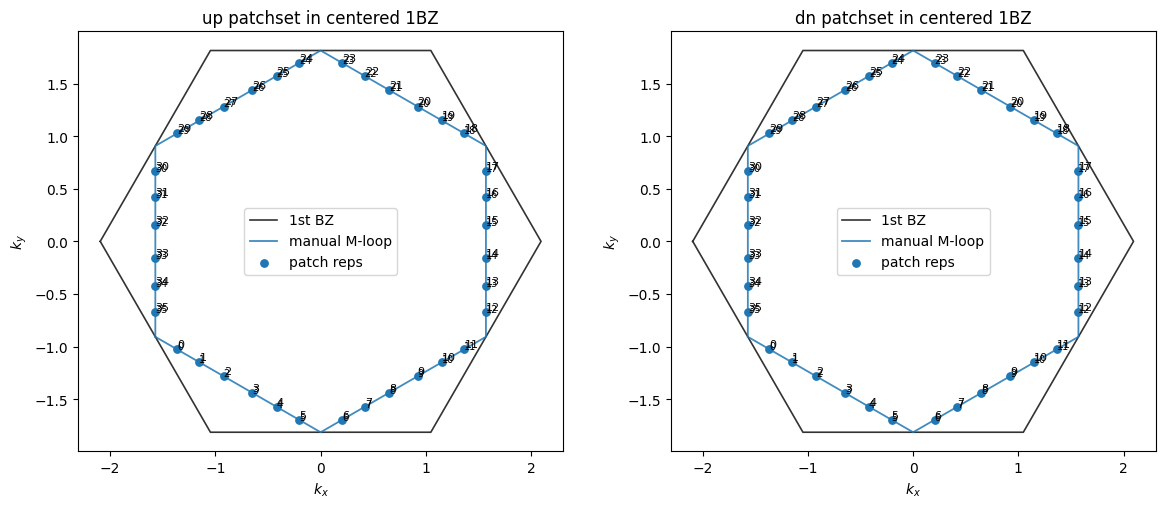

In [15]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = noninteracting.KagomeKaneMeleSOC(dict(t=1.0, l1=0.1,l2=0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 7
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"


# ============================================================
# build the final default patchsets for the whole pipeline
# ============================================================
PATCHSETS = build_tr_adapted_patchsets(
    model,
    UP_SLICE,
    DN_SLICE,
    LOCAL_BAND_INDEX,
)

# optional sanity check
defect = pp_triplet_gauge_defect(PATCHSETS)
print("pairing gauge defect max =", np.max(np.abs(defect)))
print("pairing gauge defect fro =", np.linalg.norm(defect))

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()

# Model

CASE = U_only  | U = 10.0  V = 0
T_START, T_STOP, NFREQ, NSTEPS = 5.0 0.05 50 600
NPATCH = 36
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 9.204073558733578
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


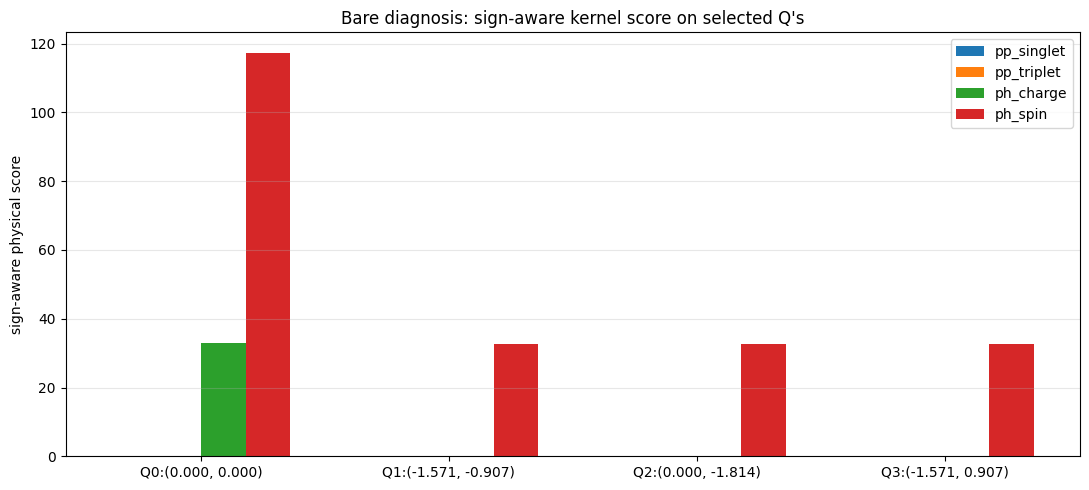


=== bare (initial) physical instability metrics ===


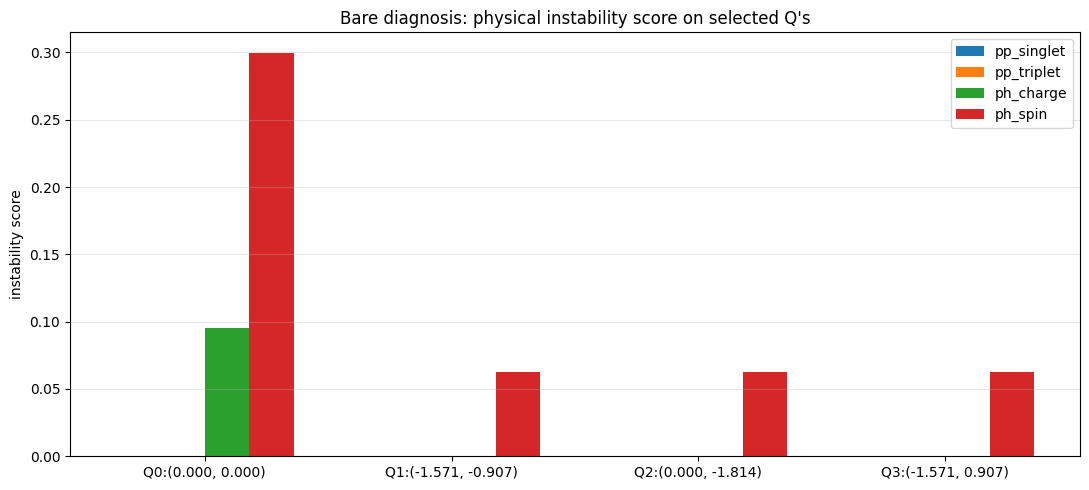

In [17]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "U_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 10., 0
# elif CASE == "V_only":
#     U_TEST, V_TEST = 0.0, 10.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 5.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 ,
    channel_divergence_threshold=1e10,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

# Flow


================ RG FLOW START ================

step=   0 | T=5.000000 | rhs_norm=0.000e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.174e+02
kernel scores: pp_singlet=6.062e-14, pp_triplet=1.272e-14, ph_charge=3.306e+01, ph_spin=1.174e+02
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=3.000e-01
instability: pp_singlet=1.491e-16, pp_triplet=3.380e-17, ph_charge=9.537e-02, ph_spin=3.000e-01
step=   5 | T=4.958681 | rhs_norm=4.409e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.152e+02
kernel scores: pp_singlet=5.971e-01, pp_triplet=3.042e-01, ph_charge=3.204e+01, ph_spin=1.152e+02
    lead_instability=ph_spin @ Q0:(0.000, 0.000) score=2.994e-01
instability: pp_singlet=2.294e-03, pp_triplet=1.312e-03, ph_charge=9.406e-02, ph_spin=2.994e-01
step=  10 | T=4.917362 | rhs_norm=4.634e+00 | lead_kernel=ph_spin @ Q0:(0.000, 0.000) score=1.130e+02
kernel scores: pp_singlet=1.194e+00, pp_triplet=5.966e-01, ph_charge=3.104e+01, ph_spin=1.130e+02
    lead_instability=ph_spin

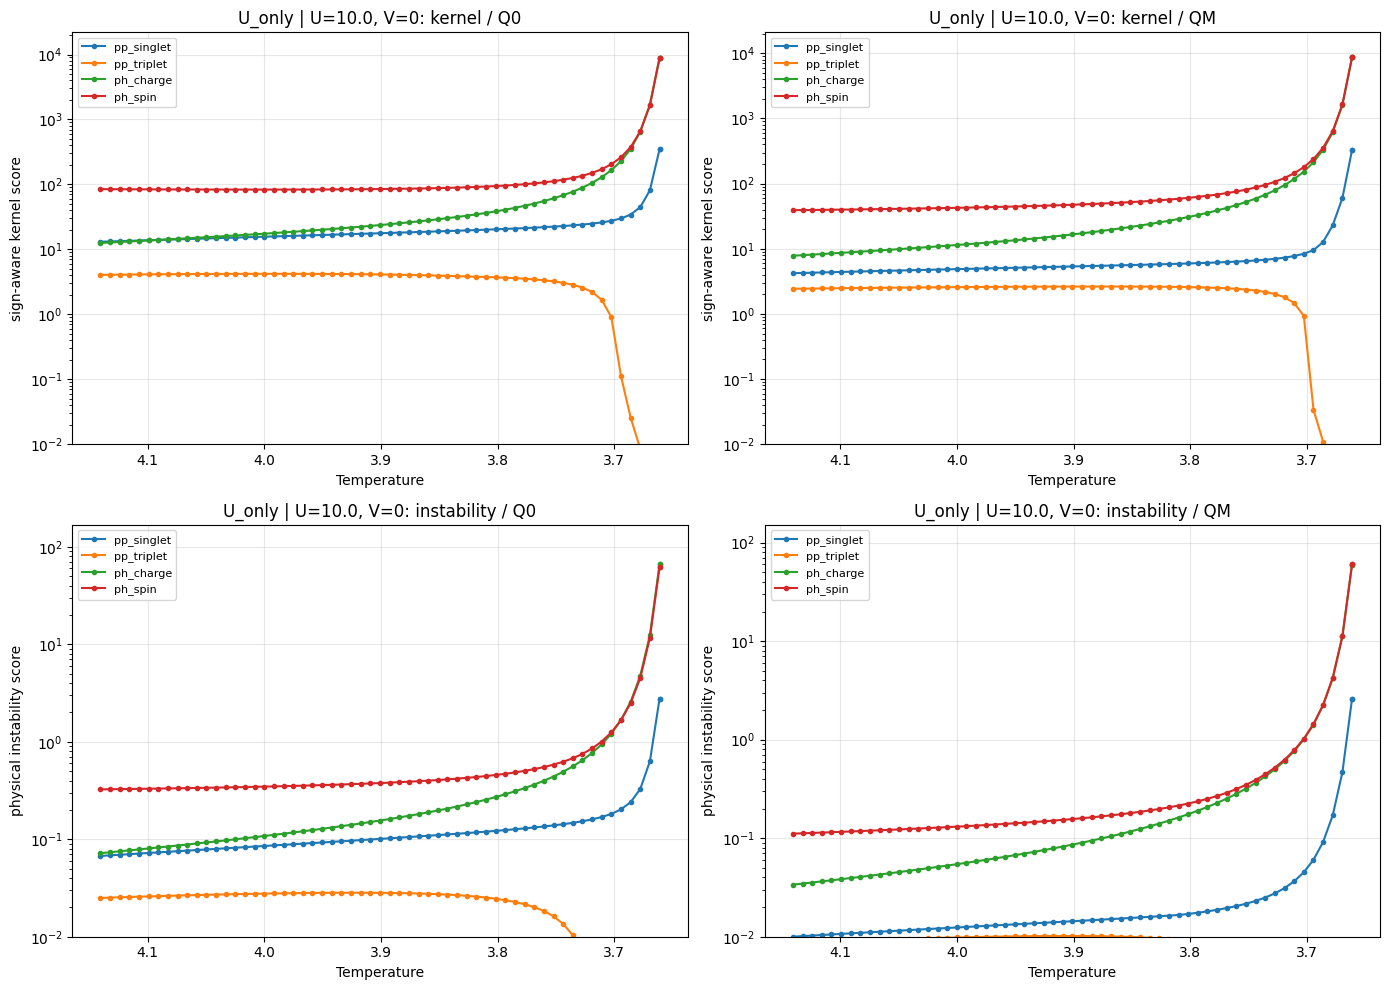

In [19]:
# ============================================================
# Flow run parameters
# ============================================================
PRINT_EVERY = 5               # print every N steps
LAST_N_STEPS_TO_PLOT = 60     # None -> plot all; integer -> only last N steps
PLOT_YLOG = True

# physical instability diagnosis options
PH_BUBBLE_MODE = "patchrep"
PROJECT_PH_CHARGE_Q0_UNIFORM = True
PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT = False


print("\n================ RG FLOW START ================\n")

# history, signaware_history_df, instability_history_df, grouped_plot_df = run_flow_with_tracking(
#     solver,
#     diagnosis_Qs,
#     print_every=PRINT_EVERY,
#     ph_bubble_mode=PH_BUBBLE_MODE,
#     project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
#     project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
# )
history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots = run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    print_every=PRINT_EVERY,
    ph_bubble_mode=PH_BUBBLE_MODE,
    project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
    project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
)

print("\n================ RG FLOW DONE ================\n")
print("history length =", len(history))

last_rec = history[-1]
print("final step =", last_rec.step_index)
print("final T    =", last_rec.temperature)
print("final rhs_norm =", last_rec.rhs_norm)
print("final channel_norm =", last_rec.channel_norm)
print("instability =", last_rec.instability)
print("terminated_early =", last_rec.terminated_early)
print("instability_reason =", last_rec.instability_reason)
print("termination_reason =", last_rec.termination_reason)

# display(signaware_history_df.tail(12))
# display(instability_history_df.tail(12))

plot_flow_group_curves(
    grouped_plot_df,
    last_n_steps=LAST_N_STEPS_TO_PLOT,
    ylog=PLOT_YLOG,
    title_prefix=f"{CASE} | U={U_TEST}, V={V_TEST}",
    ylim=1e-2
)

# Diagnosis

## Particle-Particle vs Particle-Hole

Diagnosing step_index = 159
T = 3.686060
rhs_norm = 1.465e+04
channel_norm = 3.482e+02
instability = False
terminated_early = False
instability_reason = None
termination_reason = None

=== sign-aware leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 3.746075277779e+02
chosen  : negative -3.746075277779e+02

=== physical-instability leader at selected step ===
channel : ph_charge
Q       : (0.000000, 0.000000)
score   : 2.563910408280e+00
eval    : 2.563910408280e+00
bubble  : patchrep:bubble_dot_ph(eps_p,eps_p+Q)*measure_p
proj    : nan


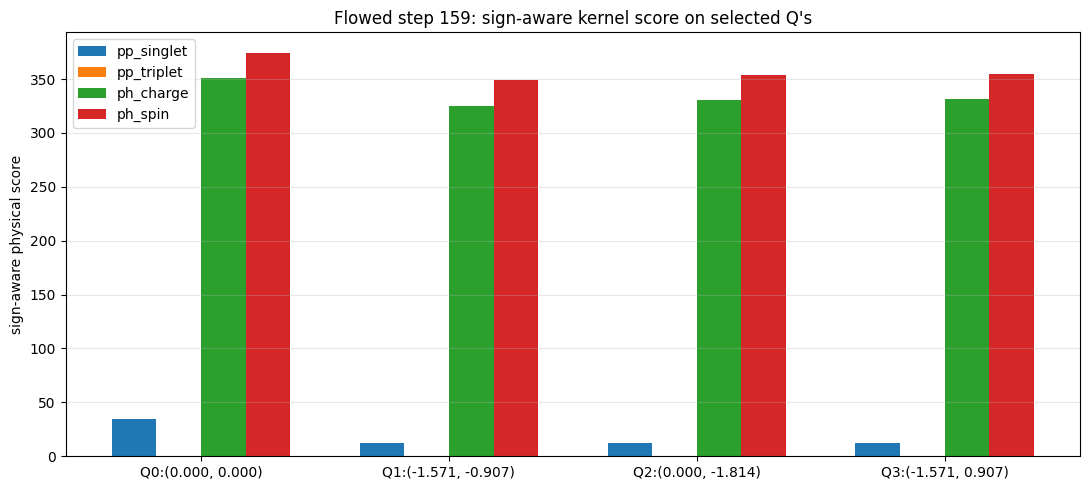

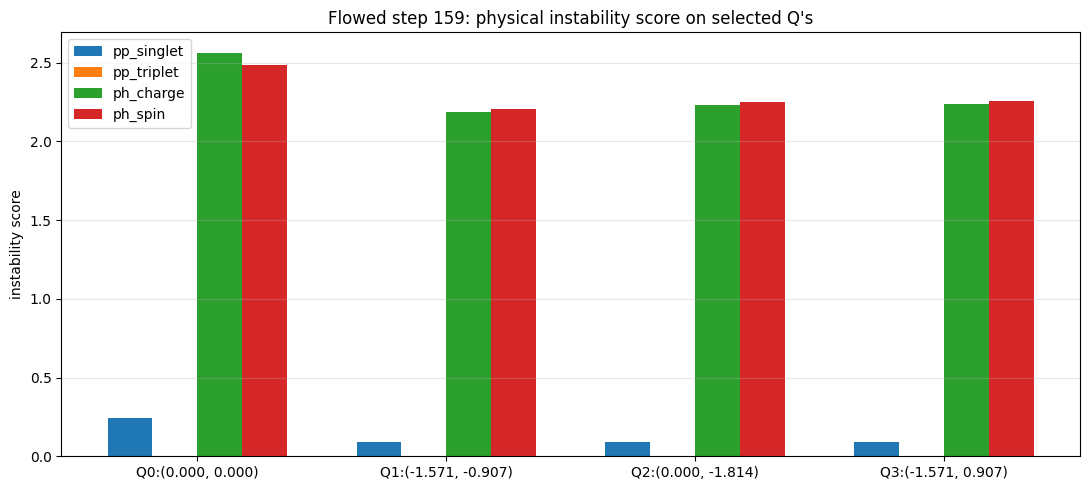

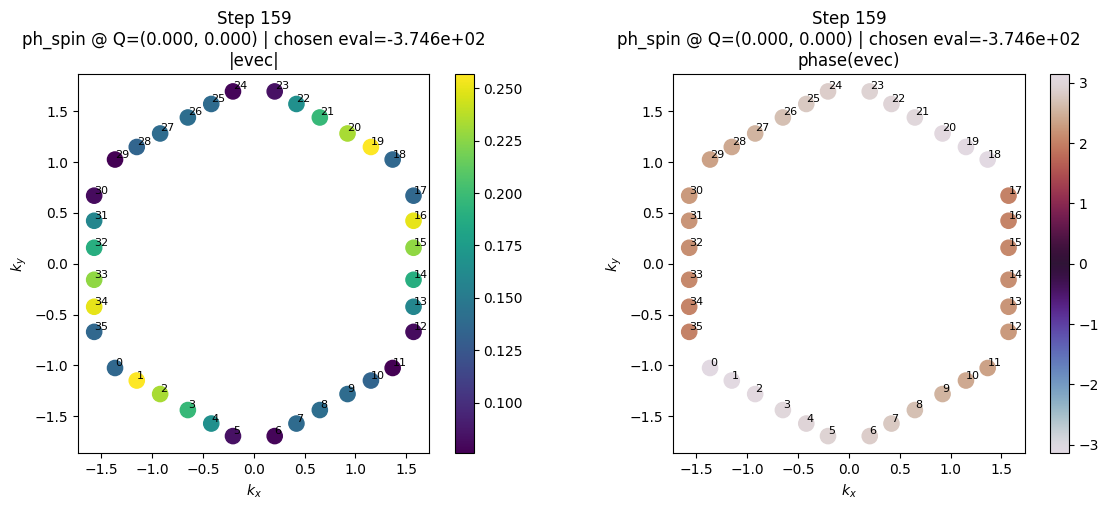

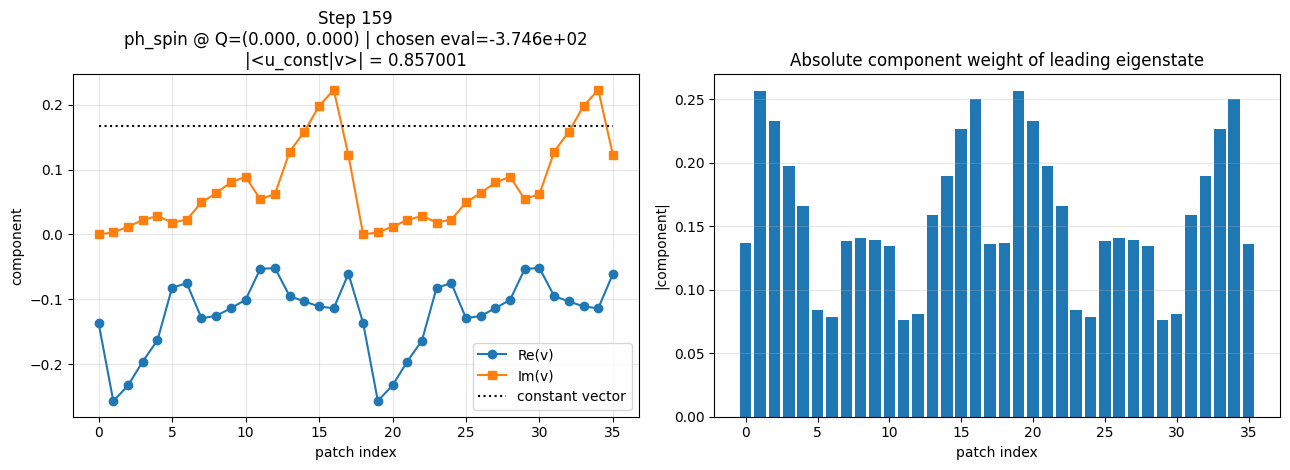


=== leader eigenstate summary ===
channel            : ph_spin
Q                  : (0.000000, 0.000000)
selected eigenvalue: -3.746075277779e+02
kernel dimension   : 36
|<u_const|v>|      : 8.570010985637e-01


In [22]:
# ============================================================
# Diagnose one flowed step
# ============================================================
STEP_SELECTOR = -5  # -1 last step, -2 second last, -3 third last, or exact step index

diagnosis_result = diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    step_selector=STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
)
# Optional: inspect the raw tables
# display(diagnosis_result["df_signaware"].sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(diagnosis_result["df_instability"].sort_values(["Q_index", "channel"]).reset_index(drop=True))

## Linear Instability

### particle-hole

,label,final_label,Q_used,kernel_name,template_family,projected_score,analysis_true_leading_score,overlap_with_instability_leader,overlap_with_analysis_leader,overlap_with_kernel_leader
0,FM,FM,[0. 0.],ph_spin,L0,0.647470,0.852380,3.374789e-01,3.374789e-01,2.517311e-07
1,SDW,SDW,[-1.570796 0.9069 ],ph_spin,L0,0.152410,0.626540,1.182952e-01,1.182952e-01,4.640261e-09
2,CDW,CDW,[-1.570796 0.9069 ],ph_charge,L0,-0.160659,0.608878,2.365615e-09,2.365615e-09,1.974312e-01
3,PI(d-wave),PI,[0. 0.],ph_charge,D,-0.668569,0.766408,1.882627e-08,1.882627e-08,4.221408e-04
4,cBO(p-wave),cBO,[-1.570796 0.9069 ],ph_charge,P,0.025545,0.608878,1.155177e-02,1.155177e-02,1.505458e-08
5,sBO(p-wave),sBO,[-1.570796 0.9069 ],ph_spin,P,0.251067,0.626540,9.554849e-02,9.554849e-02,4.278479e-08


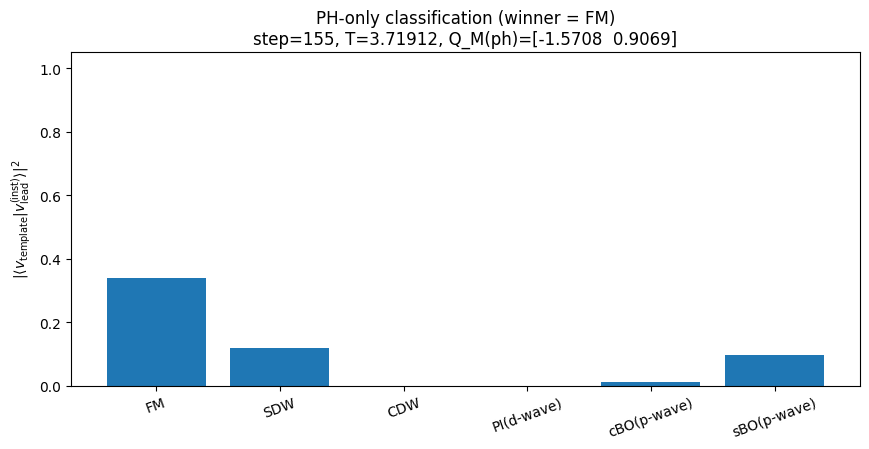

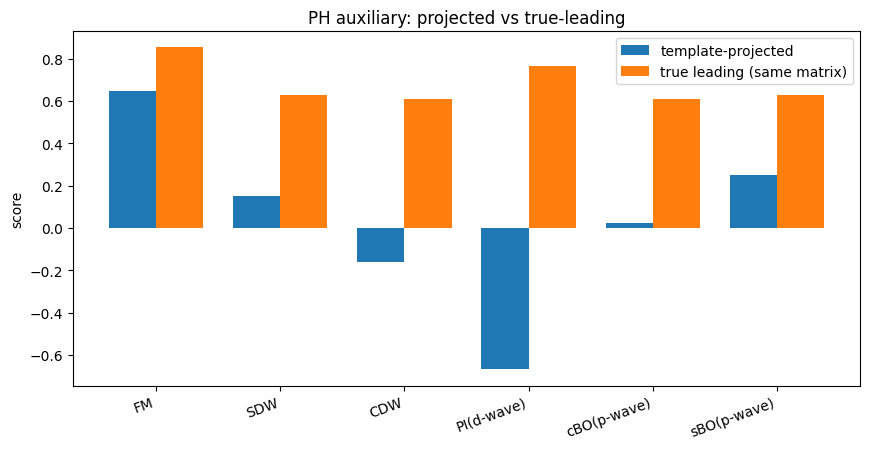

In [25]:
# ============================================================
# PH-only linear instability classification
# Main metric = overlap with instability leading eigenvector
# ============================================================
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
STEP_SELECTOR = -9

selected_rec, selected_snap = _resolve_snapshot_and_record(history, snapshots, STEP_SELECTOR)

# -------------------------------
# Resolve diagnosis Q list
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

Q0 = np.asarray(Q0_list[0], dtype=float)

# -------------------------------
# Config / templates
# -------------------------------
instability_cfg = _default_instability_config_from_solver(solver)
patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]
templates = _build_harmonic_templates_from_patchset(patchset_up)

basis_L0 = [templates["FM_L0"]]
basis_P  = templates["P_L1_basis"]
basis_D  = templates["D_L2_basis"]

# -------------------------------
# Best finite-Q for PH
# -------------------------------
Q_M_ph, _ = _choose_best_QM_for_ph(
    solver,
    QM_list,
    instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

# -------------------------------
# PH candidates only
# -------------------------------
candidate_specs_ph = [
    ("FM",          Q0,     "ph_spin",   basis_L0, "L0"),
    ("SDW",         Q_M_ph, "ph_spin",   basis_L0, "L0"),
    ("CDW",         Q_M_ph, "ph_charge", basis_L0, "L0"),
    ("PI(d-wave)",  Q0,     "ph_charge", basis_D,  "D"),
    ("cBO(p-wave)", Q_M_ph, "ph_charge", basis_P,  "P"),
    ("sBO(p-wave)", Q_M_ph, "ph_spin",   basis_P,  "P"),
]

rows_ph = []
for label, Q_use, kernel_name, basis, family in candidate_specs_ph:
    pack = _evaluate_candidate_family_dual_overlap(
        solver,
        Q_use,
        kernel_name,
        basis,
        family,
        instability_cfg,
        snapshot=selected_snap,
        use_operator=USE_BUBBLE_DRESSED_OPERATOR,
        Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
    )
    rows_ph.append({
        "label": label,
        "final_label": pack["final_label"],
        "Q_used": np.array2string(np.asarray(Q_use), precision=6),
        "kernel_name": kernel_name,
        "template_family": family,
        "projected_score": float(pack["projected_score"]),
        "analysis_true_leading_score": float(pack["analysis_true_leading_score"]),
        "overlap_with_instability_leader": float(pack["overlap_with_instability_leader"]),
        "overlap_with_analysis_leader": float(pack["overlap_with_analysis_leader"]),
        "overlap_with_kernel_leader": float(pack["overlap_with_kernel_leader"]),
    })

df_ph = pd.DataFrame(rows_ph)
winner_idx = int(np.argmax(df_ph["overlap_with_instability_leader"].to_numpy(float)))
winner_row = df_ph.iloc[winner_idx]

display(df_ph)

# -------------------------------
# Figure 1: main classification metric
# -------------------------------
labels = df_ph["label"].tolist()
overlaps_inst = df_ph["overlap_with_instability_leader"].to_numpy(dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.6))
ax.bar(labels, overlaps_inst)
ax.set_ylim(0, 1.05)
ax.set_ylabel(r"$|\langle v_{\rm template}|v_{\rm lead}^{(\rm inst)}\rangle|^2$")
ax.set_title(
    f"PH-only classification (winner = {winner_row['final_label']})\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}, "
    f"Q_M(ph)={np.array2string(Q_M_ph, precision=4)}"
)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# -------------------------------
# Figure 2: auxiliary diagnostics
# -------------------------------
projected_scores = df_ph["projected_score"].to_numpy(dtype=float)
analysis_true_scores = df_ph["analysis_true_leading_score"].to_numpy(dtype=float)
overlaps_kernel = df_ph["overlap_with_kernel_leader"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 1, figsize=(8.8, 4.6))
x = np.arange(len(labels))
w = 0.38

axes.bar(x - w/2, projected_scores, width=w, label="template-projected")
axes.bar(x + w/2, analysis_true_scores, width=w, label="true leading (same matrix)")
axes.set_xticks(x)
axes.set_xticklabels(labels, rotation=20, ha="right")
axes.set_ylabel("score")
axes.set_title("PH auxiliary: projected vs true-leading")
axes.legend()

# axes[1].bar(labels, overlaps_kernel)
# axes[1].set_ylim(0, 1.05)
# axes[1].set_ylabel(r"$|\langle v_{\rm template}|v_{\rm lead}^{(\rm kernel)}\rangle|^2$")
# axes[1].set_title("PH auxiliary: overlap with raw kernel leader")
# axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Particle-Particle

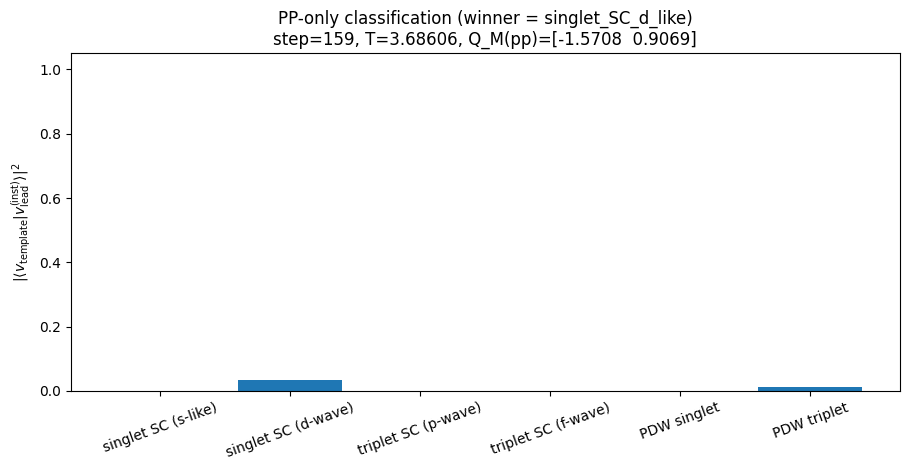

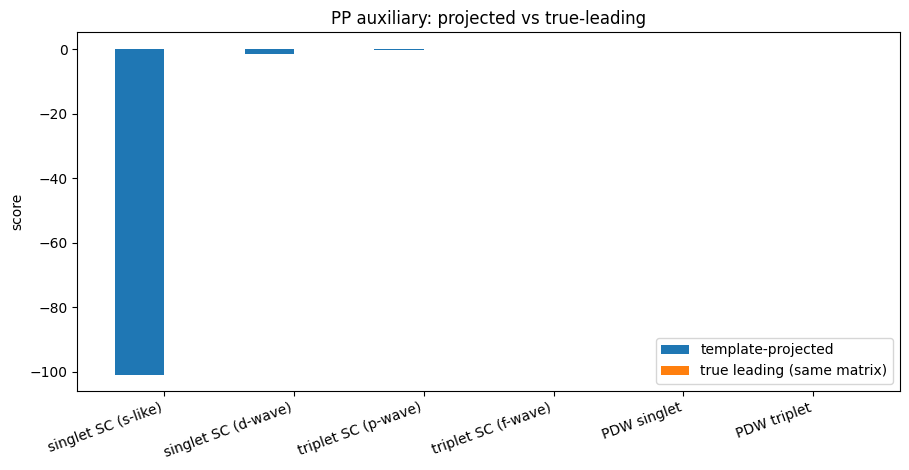

In [27]:
# ============================================================
# PP-only linear instability classification
# Main metric = overlap with instability leading eigenvector
# ============================================================
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
STEP_SELECTOR = -5

selected_rec, selected_snap = _resolve_snapshot_and_record(history, snapshots, STEP_SELECTOR)

# -------------------------------
# Resolve diagnosis Q list
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

Q0 = np.asarray(Q0_list[0], dtype=float)

# -------------------------------
# Config / templates
# -------------------------------
instability_cfg = _default_instability_config_from_solver(solver)
patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]
templates = _build_harmonic_templates_from_patchset(patchset_up)

basis_L0 = [templates["FM_L0"]]
basis_D  = templates["D_L2_basis"]
basis_P  = templates["P_L1_basis"]
basis_F  = templates["F_L3_basis"]

# -------------------------------
# Best finite-Q for PP
# -------------------------------
Q_M_pp, _ = _choose_best_QM_for_pp(
    solver,
    QM_list,
    instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

# -------------------------------
# PP candidates only
# -------------------------------
candidate_specs_pp = [
    ("singlet SC (s-like)",  Q0,     "pp_singlet", basis_L0, "L0"),
    ("singlet SC (d-wave)",  Q0,     "pp_singlet", basis_D,  "D"),
    ("triplet SC (p-wave)",  Q0,     "pp_triplet", basis_P,  "P"),
    ("triplet SC (f-wave)",  Q0,     "pp_triplet", basis_F,  "F"),
    ("PDW singlet",          Q_M_pp, "pp_singlet", basis_D,  "D"),
    ("PDW triplet",          Q_M_pp, "pp_triplet", basis_P,  "P"),
]

rows_pp = []
for label, Q_use, kernel_name, basis, family in candidate_specs_pp:
    pack = _evaluate_candidate_family_dual_overlap(
        solver,
        Q_use,
        kernel_name,
        basis,
        family,
        instability_cfg,
        snapshot=selected_snap,
        use_operator=USE_BUBBLE_DRESSED_OPERATOR,
        Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
    )
    rows_pp.append({
        "label": label,
        "final_label": pack["final_label"],
        "Q_used": np.array2string(np.asarray(Q_use), precision=6),
        "kernel_name": kernel_name,
        "template_family": family,
        "projected_score": float(pack["projected_score"]),
        "analysis_true_leading_score": float(pack["analysis_true_leading_score"]),
        "overlap_with_instability_leader": float(pack["overlap_with_instability_leader"]),
        "overlap_with_analysis_leader": float(pack["overlap_with_analysis_leader"]),
        "overlap_with_kernel_leader": float(pack["overlap_with_kernel_leader"]),
    })

df_pp = pd.DataFrame(rows_pp)
winner_idx = int(np.argmax(df_pp["overlap_with_instability_leader"].to_numpy(float)))
winner_row = df_pp.iloc[winner_idx]

# display(df_pp)

# -------------------------------
# Figure 1: main classification metric
# -------------------------------
labels = df_pp["label"].tolist()
overlaps_inst = df_pp["overlap_with_instability_leader"].to_numpy(dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(9.2, 4.8))
ax.bar(labels, overlaps_inst)
ax.set_ylim(0, 1.05)
ax.set_ylabel(r"$|\langle v_{\rm template}|v_{\rm lead}^{(\rm inst)}\rangle|^2$")
ax.set_title(
    f"PP-only classification (winner = {winner_row['final_label']})\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}, "
    f"Q_M(pp)={np.array2string(Q_M_pp, precision=4)}"
)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# -------------------------------
# Figure 2: auxiliary diagnostics
# -------------------------------
projected_scores = df_pp["projected_score"].to_numpy(dtype=float)
analysis_true_scores = df_pp["analysis_true_leading_score"].to_numpy(dtype=float)
overlaps_kernel = df_pp["overlap_with_kernel_leader"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 1, figsize=(9.2, 4.8))
x = np.arange(len(labels))
w = 0.38

axes.bar(x - w/2, projected_scores, width=w, label="template-projected")
axes.bar(x + w/2, analysis_true_scores, width=w, label="true leading (same matrix)")
axes.set_xticks(x)
axes.set_xticklabels(labels, rotation=20, ha="right")
axes.set_ylabel("score")
axes.set_title("PP auxiliary: projected vs true-leading")
axes.legend()

# axes[1].bar(labels, overlaps_kernel)
# axes[1].set_ylim(0, 1.05)
# axes[1].set_ylabel(r"$|\langle v_{\rm template}|v_{\rm lead}^{(\rm kernel)}\rangle|^2$")
# axes[1].set_title("PP auxiliary: overlap with raw kernel leader")
# axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Double Order

,label,overlap_with_leading_subspace,template_projected_score,true_leading_score_same_matrix,leading_group_dim,score_if_available
0,charge LC @ Q0,NaN,NaN,NaN,1,NaN
1,charge LC @ QM,NaN,NaN,NaN,1,NaN
2,spin LC @ Q0,0.451985,-0.381214,0.749532,2,0.749532
3,spin LC @ QM,0.001989,0.210125,0.521149,2,0.521149
4,chiral singlet SC @ Q0,NaN,NaN,NaN,1,NaN
5,chiral triplet SC @ Q0,NaN,NaN,NaN,1,NaN


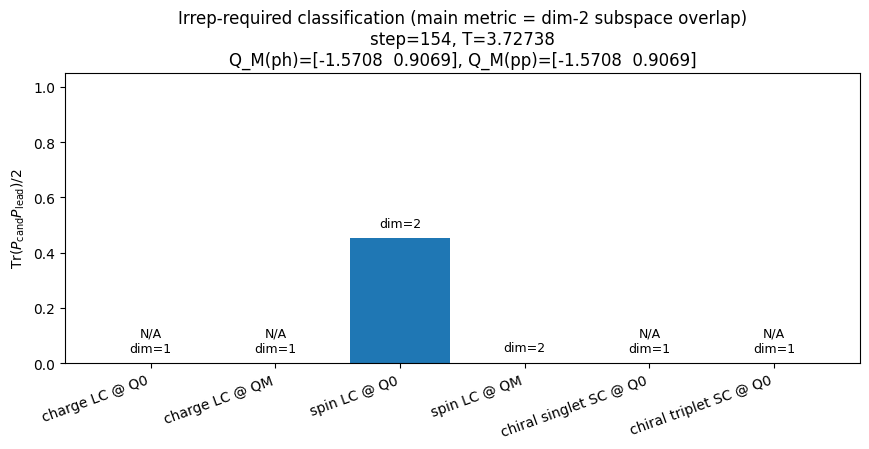

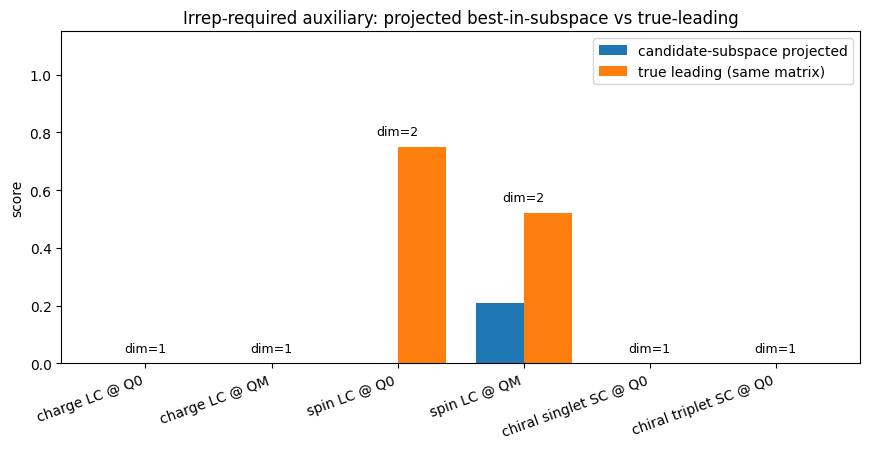

In [79]:

USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
STEP_SELECTOR = -10

# -------------------------------
# Resolve step + diagnosis Qs
# -------------------------------
selected_rec, selected_snap = _resolve_record_and_snapshot_by_step_index(
    history, snapshots,
    history[STEP_SELECTOR].step_index if isinstance(STEP_SELECTOR, int) and STEP_SELECTOR < 0 else STEP_SELECTOR
)

if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

Q0 = np.asarray(Q0_list[0], dtype=float)
instability_cfg = _default_instability_config_from_solver(solver)

# -------------------------------
# Build needed dicts here
# -------------------------------
kdict_Q0, idict_Q0 = _build_kernel_and_instability_dict(
    solver,
    Q0,
    instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

Q_M_ph, kdict_M_ph, idict_M_ph = _choose_QM_for_snapshot_ph(
    solver,
    selected_snap,
    QM_list,
    instability_cfg,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

Q_M_pp, kdict_M_pp, idict_M_pp = _choose_QM_for_snapshot_pp(
    solver,
    selected_snap,
    QM_list,
    instability_cfg,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
)

# -------------------------------
# Harmonic templates already available in your notebook ecosystem
# -------------------------------
patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]
templates = _build_harmonic_templates_from_patchset(patchset_up)

# -------------------------------
# Candidate specs
# -------------------------------
candidate_specs = [
    ("charge LC @ Q0",          kdict_Q0["ph_charge"],   idict_Q0["ph_charge"]),
    ("charge LC @ QM",          kdict_M_ph["ph_charge"], idict_M_ph["ph_charge"]),
    ("spin LC @ Q0",            kdict_Q0["ph_spin"],     idict_Q0["ph_spin"]),
    ("spin LC @ QM",            kdict_M_ph["ph_spin"],   idict_M_ph["ph_spin"]),
    ("chiral singlet SC @ Q0",  kdict_Q0["pp_singlet"],  idict_Q0["pp_singlet"]),
    ("chiral triplet SC @ Q0",  kdict_Q0["pp_triplet"],  idict_Q0["pp_triplet"]),
]

rows = []
for label, ker, res in candidate_specs:
    dim = _leading_group_dim(res)
    lead_basis = _leading_group_basis(res)
    parent_score = _leading_group_score(res)

    overlap_subspace = np.nan
    projected_score = np.nan
    true_leading_score = np.nan

    # only keep overlap meaningful for dim == 2
    if dim == 2 and lead_basis is not None:
        cand_basis = _candidate_basis_from_label(label, templates)

        # meaningful overlap: candidate 2D harmonic subspace vs leading 2D multiplet subspace
        overlap_subspace = _subspace_overlap_dim2(cand_basis, lead_basis)

        # same analysis matrix convention as the rest of your notebook
        M_analysis = _analysis_matrix_from_result(
            ker,
            res,
            use_operator=USE_BUBBLE_DRESSED_OPERATOR,
        )

        # correct projected score: best direction inside candidate subspace
        projected_score = _best_score_in_dim2_subspace(M_analysis, cand_basis)

        # true leading score from the same matrix
        true_leading_score = _true_leading_score_same_matrix(M_analysis)

    rows.append({
        "label": label,
        "overlap_with_leading_subspace": overlap_subspace,
        "template_projected_score": projected_score,
        "true_leading_score_same_matrix": true_leading_score,
        "leading_group_dim": dim,
        "score_if_available": parent_score,
    })

df_irrep = pd.DataFrame(rows)
display(df_irrep)

# -------------------------------
# Figure 1: main classification metric
# -------------------------------
labels = df_irrep["label"].tolist()
overlaps = df_irrep["overlap_with_leading_subspace"].to_numpy(dtype=float)
dims = df_irrep["leading_group_dim"].to_numpy(dtype=int)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.6))
x = np.arange(len(labels))

overlaps_plot = np.nan_to_num(overlaps, nan=0.0)
colors = ["C0" if np.isfinite(v) else "lightgray" for v in overlaps]
ax.bar(x, overlaps_plot, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel(r"$\mathrm{Tr}(P_{\rm cand}P_{\rm lead})/2$")
ax.set_title(
    "Irrep-required classification (main metric = dim-2 subspace overlap)\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}\n"
    f"Q_M(ph)={np.array2string(Q_M_ph, precision=4)}, "
    f"Q_M(pp)={np.array2string(Q_M_pp, precision=4)}"
)

for i, (ov, dim) in enumerate(zip(overlaps, dims)):
    if np.isnan(ov):
        ax.text(i, 0.03, f"N/A\ndim={dim}", ha="center", va="bottom", fontsize=9)
    else:
        ax.text(i, min(ov + 0.03, 1.0), f"dim={dim}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------
# Figure 2: auxiliary diagnostics
# -------------------------------
projected_scores = df_irrep["template_projected_score"].to_numpy(dtype=float)
true_leading_scores = df_irrep["true_leading_score_same_matrix"].to_numpy(dtype=float)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 4.6))
x = np.arange(len(labels))
w = 0.38

ax.bar(x - w/2, np.nan_to_num(projected_scores, nan=0.0), width=w, label="candidate-subspace projected")
ax.bar(x + w/2, np.nan_to_num(true_leading_scores, nan=0.0), width=w, label="true leading (same matrix)")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("score")
ax.set_title("Irrep-required auxiliary: projected best-in-subspace vs true-leading")
ax.legend()

ymax = max(
    1.0,
    np.nanmax(np.nan_to_num(projected_scores, nan=0.0)),
    np.nanmax(np.nan_to_num(true_leading_scores, nan=0.0)),
)
ax.set_ylim(0, 1.15 * ymax)

for i, dim in enumerate(dims):
    ytxt = max(
        np.nan_to_num(projected_scores[i], nan=0.0),
        np.nan_to_num(true_leading_scores[i], nan=0.0),
    ) + 0.03 * ymax
    ax.text(i, ytxt, f"dim={dim}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Comparison

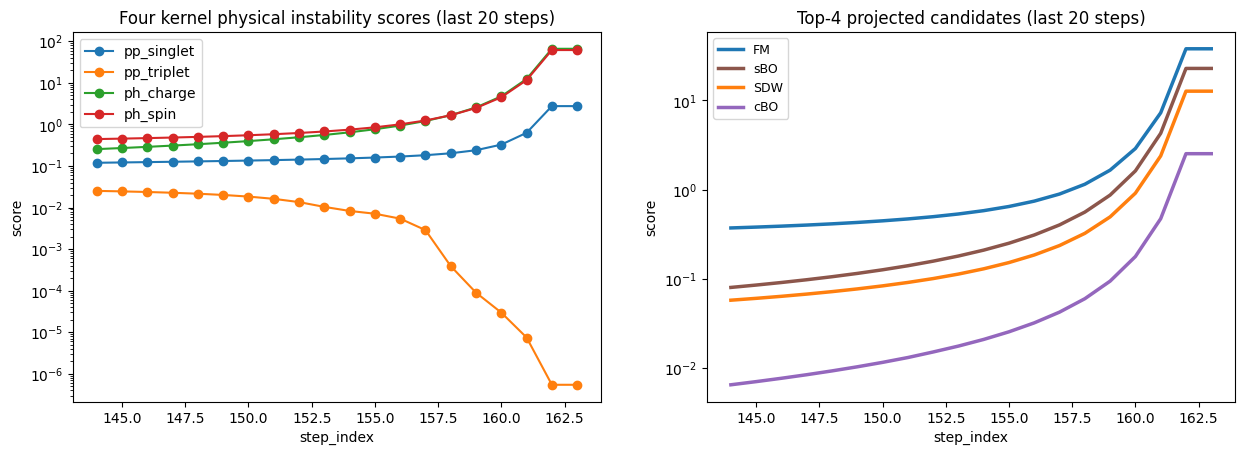

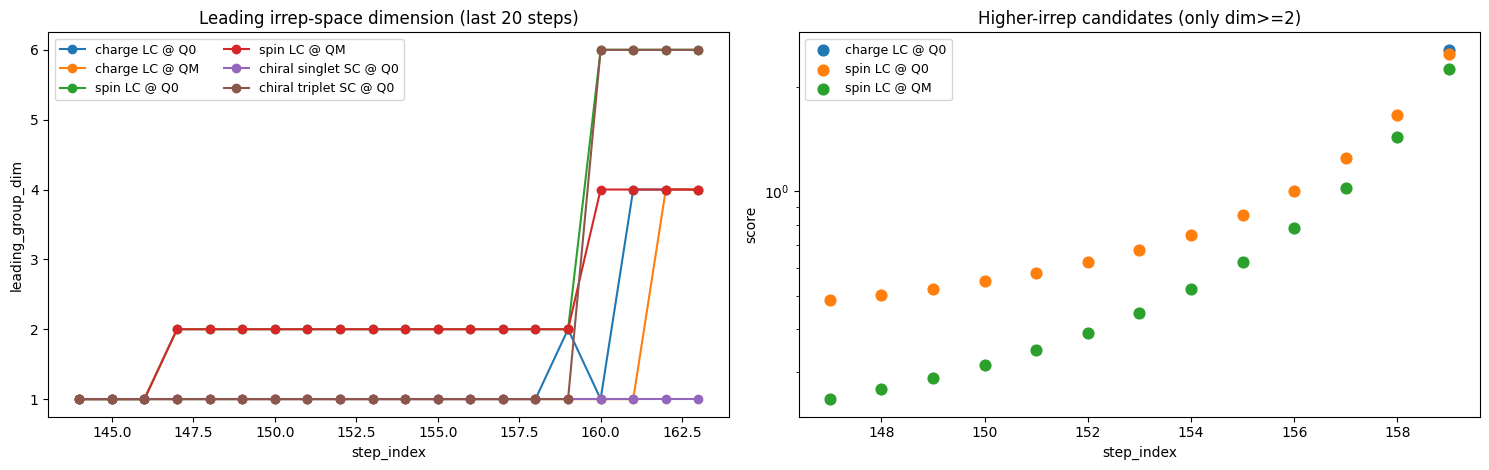

In [47]:
# ============================================================
# Last-N-step line plots with new logic
# ============================================================

# -------------------------------
# User controls
# -------------------------------
LAST_N_STEPS = 20
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
X_AXIS = "step_index"   # or "T"

# -------------------------------
# Resolve diagnosis_Qs
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

# -------------------------------
# Build time series
# -------------------------------
(
    df_kernel_scores_ts,
    df_projected_single_ts,
    df_irrep_dim_ts,
    df_irrep_scores_ts,
    df_meta_ts,
) = collect_order_timeseries_new(
    solver,
    history,
    snapshots,
    diagnosis_Qs=diag_Qs,
    last_n_steps=LAST_N_STEPS,
    USE_BUBBLE_DRESSED_OPERATOR=USE_BUBBLE_DRESSED_OPERATOR,
    Landau_F_FOR_CHANNEL_BUILD=Landau_F_FOR_CHANNEL_BUILD,
)

# display(df_meta_ts)

# Optional:
# display(df_kernel_scores_ts)
# display(df_projected_single_ts)
# display(df_irrep_dim_ts)
# display(df_irrep_scores_ts)

# -------------------------------
# Plot
# -------------------------------
plot_order_timeseries_new(
    df_kernel_scores_ts,
    df_projected_single_ts,
    df_irrep_dim_ts,
    df_irrep_scores_ts,
    x_axis=X_AXIS,
    title_suffix=f" (last {LAST_N_STEPS} steps)",
)

# Debug

In [115]:
# ============================================================
# Correct helper: inspect the SAME analysis matrix used by PH-only classification
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels as chmod
import instability as inst
import frg_flow as flowmod

# -------------------------------
# User controls
# -------------------------------
STEP_SELECTOR_ANALYSIS = -8
USE_BUBBLE_DRESSED_OPERATOR_LOCAL = globals().get("USE_BUBBLE_DRESSED_OPERATOR", True)

# -------------------------------
# Basic checks
# -------------------------------
required = ["solver", "history", "diagnosis_Qs"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required notebook objects: {missing}")

# -------------------------------
# Reuse earlier helpers if present; otherwise define minimal versions
# -------------------------------
def _resolve_step_index(history, step_selector):
    n = len(history)
    if n == 0:
        raise RuntimeError("history is empty")
    if isinstance(step_selector, int) and step_selector < 0:
        idx = n + step_selector
    else:
        idx = int(step_selector)
    if idx < 0 or idx >= n:
        raise IndexError(f"step_selector={step_selector} resolved to idx={idx}, out of range for history length={n}")
    return idx

def _sz0tensor3_to_4d(vertex3):
    data = np.asarray(vertex3.data, dtype=complex)
    p4_index = np.asarray(vertex3.p4_index, dtype=int)
    Np = data.shape[0]
    out = np.zeros((Np, Np, Np, Np), dtype=complex)
    for p1 in range(Np):
        for p2 in range(Np):
            for p3 in range(Np):
                p4 = int(p4_index[p1, p2, p3])
                if 0 <= p4 < Np:
                    out[p1, p2, p3, p4] = data[p1, p2, p3]
    return out

def _vertex4_from_any(obj):
    if isinstance(obj, np.ndarray):
        arr = np.asarray(obj, dtype=complex)
        if arr.ndim == 4:
            return arr
        raise ValueError(f"Expected 4D ndarray, got shape={arr.shape}")
    if hasattr(obj, "data") and hasattr(obj, "p4_index"):
        return _sz0tensor3_to_4d(obj)
    if hasattr(obj, "vertex"):
        return _vertex4_from_any(obj.vertex)
    if isinstance(obj, dict):
        for key in ["vertex", "state_vertex", "vertex_tensor", "snapshot_vertex"]:
            if key in obj:
                return _vertex4_from_any(obj[key])
    raise RuntimeError(f"Could not extract 4D vertex from object of type {type(obj)}")

def _get_vertex4_for_step(step_selector):
    idx = _resolve_step_index(history, step_selector)

    if "snapshots" in globals():
        snaps = globals()["snapshots"]
        try:
            if len(snaps) > idx:
                return _vertex4_from_any(snaps[idx]), idx, "snapshots[idx]"
        except Exception:
            pass

    if "make_snapshot_from_history_record" in globals():
        try:
            snap = make_snapshot_from_history_record(history[idx])
            return _vertex4_from_any(snap), idx, "make_snapshot_from_history_record(history[idx])"
        except Exception:
            pass

    rec = history[idx]
    for key in ["vertex", "state_vertex", "vertex_tensor", "snapshot"]:
        if hasattr(rec, key):
            try:
                return _vertex4_from_any(getattr(rec, key)), idx, f"history[idx].{key}"
            except Exception:
                pass

    if idx == len(history) - 1:
        return _vertex4_from_any(solver.state.vertex), idx, "solver.state.vertex (final fallback)"

    raise RuntimeError(
        "Could not recover flowed vertex for the requested step. "
        "For non-final-step tests, you need snapshots or a working snapshot helper."
    )

def _get_temperature_for_step(step_idx):
    rec = history[step_idx]
    if hasattr(rec, "temperature"):
        return float(rec.temperature)
    if step_idx == len(history) - 1 and hasattr(solver.state, "T"):
        return float(solver.state.T)
    raise RuntimeError("Could not determine temperature for selected step")

def _q0_from_diagnosis_Qs(Qs):
    for q in Qs:
        q = np.asarray(q, dtype=float)
        if np.allclose(q, 0.0, atol=1e-12, rtol=0.0):
            return q
    raise RuntimeError("diagnosis_Qs does not contain Q=0")

def _make_instability_config():
    cfg = inst.InstabilityConfig()
    cfg.analyze_multiplets = True
    cfg.build_complex_candidates = True
    cfg.patch_measure_mode = str(getattr(solver, "patch_measure_mode", "unit"))
    cfg.patch_measure_soft_vf_eps = getattr(solver, "patch_measure_soft_vf_eps", None)
    cfg.patch_measure_normalize_mean = bool(getattr(solver, "patch_measure_normalize_mean", False))
    cfg.project_ph_charge_q0_uniform = True
    cfg.project_pp_singlet_q0_local_gram_default = False
    return cfg

def _build_channel_kernel(vertex4, channel_name, Q):
    builder = chmod.SZ0ChannelBuilder.from_solver(vertex4, solver, Landau_F=False, q0_tol=1e-10)
    if channel_name == "ph_spin":
        return builder.ph_spin(Q)
    elif channel_name == "ph_charge":
        return builder.ph_charge(Q)
    elif channel_name == "pp_singlet":
        return builder.pp_singlet(Q)
    elif channel_name == "pp_triplet":
        return builder.pp_triplet(Q)
    else:
        raise ValueError(f"Unsupported channel_name={channel_name!r}")

def _diagnose_channel(vertex4, temperature, channel_name, Q):
    ker = _build_channel_kernel(vertex4, channel_name, Q)
    cfg = _make_instability_config()
    flow_cfg = flowmod.FlowConfig(
        temperature=float(temperature),
        nfreq=int(getattr(solver, "nfreq", 128)),
        include_explicit_T_prefactor=bool(getattr(solver, "include_explicit_T_prefactor", True)),
    )
    res = inst.diagnose_channel_instability(
        ker,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=cfg,
    )
    return ker, res

def _get_analysis_matrix_and_result(step_selector, channel_name, Q, use_bubble_dressed_operator=True):
    vertex4, step_idx, vertex_source = _get_vertex4_for_step(step_selector)
    temperature = _get_temperature_for_step(step_idx)
    ker, res = _diagnose_channel(vertex4, temperature, channel_name, Q)

    if use_bubble_dressed_operator:
        # Use the exact instability operator your PH-only classification is based on
        M = res.operator_projected if res.operator_projected is not None else res.operator_unprojected
        matrix_label = "bubble_dressed_operator"
    else:
        M = ker.hermitian_matrix()
        matrix_label = "raw_hermitian_kernel"

    M = np.asarray(M, dtype=complex)
    return {
        "matrix": M,
        "matrix_label": matrix_label,
        "result": res,
        "kernel": ker,
        "step_idx": step_idx,
        "temperature": temperature,
        "vertex_source": vertex_source,
    }

def _const_template(N):
    t = np.ones(N, dtype=complex)
    return t / np.linalg.norm(t)

print("Correct analysis-matrix helper is ready.")

Correct analysis-matrix helper is ready.


Using step_idx=156, T=3.71085142, vertex_source=snapshots[idx]
analysis object = bubble_dressed_operator
single_mode_label = spin_nematic_like_or_q0_spin_bond_like
leading_score = 1.0050610897204861
Top eigenvalues:
  0: 1.0050610897
  1: 0.9829365766
  2: 0.9763443489
  3: 0.8467721949
  4: 0.8123554231
  5: 0.8097019139

FM total weight in top-N subspace = 0.5622379333816018


,mode_index,eigenvalue,FM_overlap_sq_with_mode,weighted_contribution_lambda_times_overlap
0,0,1.005061,2.301744e-01,2.313394e-01
1,1,0.982937,3.019016e-01,2.967501e-01
2,2,0.976344,2.118356e-03,2.068245e-03
3,3,0.846772,2.803840e-02,2.374214e-02
4,4,0.812355,2.997635e-07,2.435145e-07
5,5,0.809702,4.890125e-06,3.959544e-06


FM overlap with leading eigenvector on SAME matrix = 0.23017441989970577


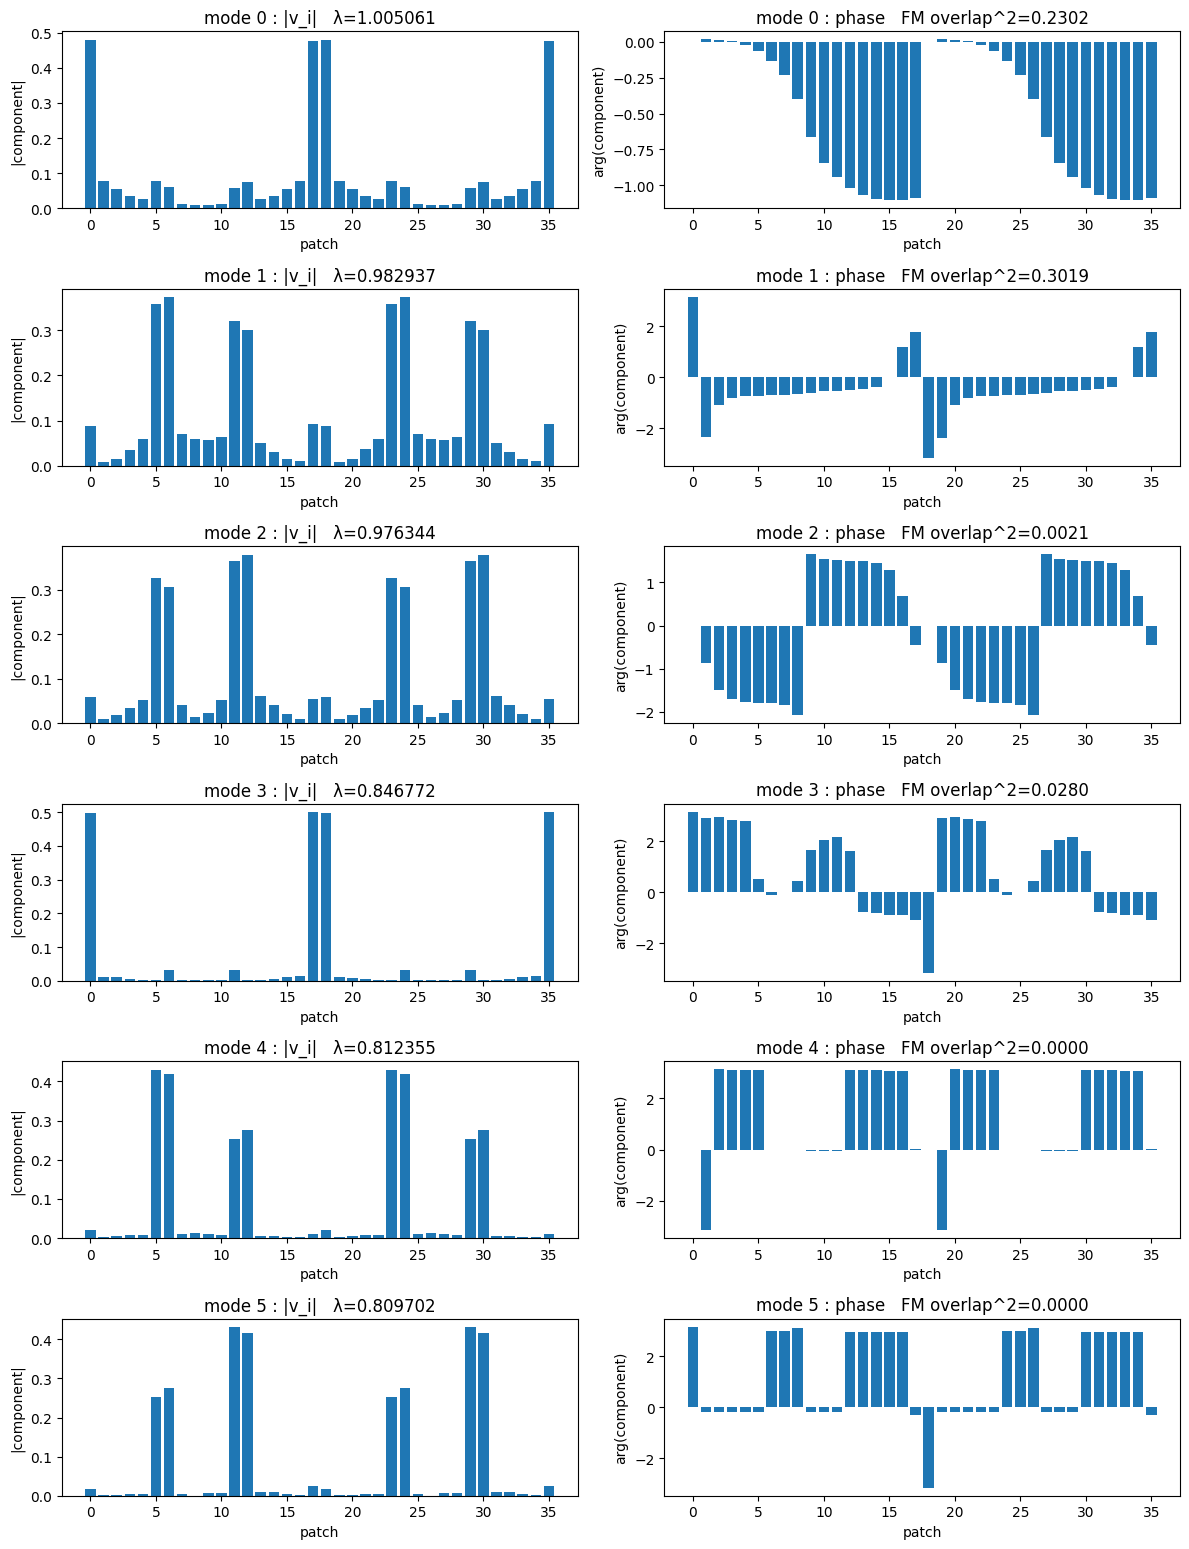

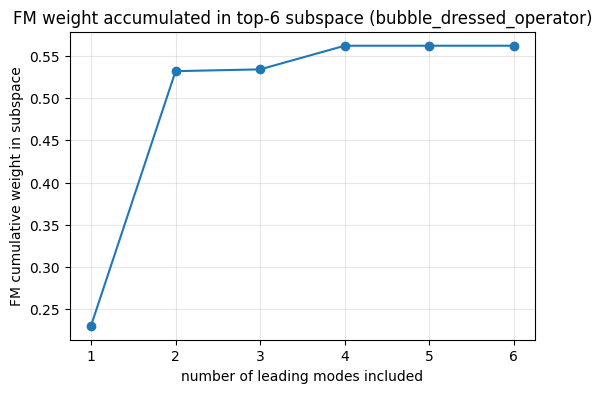

,step_idx,temperature,matrix_label,lambda1,lambda2,lambda6,relative_spread_topN,FM_overlap_with_mode0,FM_total_weight_in_topN
0,156,3.710851,bubble_dressed_operator,1.005061,0.982937,0.809702,0.194375,0.230174,0.562238


In [117]:
# ============================================================
# Correct Test 1: analyze the SAME matrix used by PH-only classification
# Example: q=0 ph-spin
# ============================================================
CHANNEL_NAME = "ph_spin"
Q_ANALYSIS = _q0_from_diagnosis_Qs(diagnosis_Qs)
TOP_N = 6

pack = _get_analysis_matrix_and_result(
    STEP_SELECTOR_ANALYSIS,
    CHANNEL_NAME,
    Q_ANALYSIS,
    use_bubble_dressed_operator=USE_BUBBLE_DRESSED_OPERATOR_LOCAL,
)

M = pack["matrix"]
res = pack["result"]

print(f"Using step_idx={pack['step_idx']}, T={pack['temperature']:.8f}, vertex_source={pack['vertex_source']}")
print(f"analysis object = {pack['matrix_label']}")
print(f"single_mode_label = {res.single_mode_label}")
print(f"leading_score = {res.score}")

# diagonalize the SAME matrix used in classification
evals, evecs = np.linalg.eigh(M)
order = np.argsort(evals)[::-1]
evals = np.asarray(evals[order], dtype=float)
evecs = np.asarray(evecs[:, order], dtype=complex)

Nkeep = min(TOP_N, len(evals))
E = evals[:Nkeep]
V = evecs[:, :Nkeep]

print("Top eigenvalues:")
for i, lam in enumerate(E):
    print(f"  {i}: {lam:.10f}")

# FM template on the SAME matrix
Np = V.shape[0]
t_fm = _const_template(Np)

fm_mode_weights = np.abs(V.conj().T @ t_fm) ** 2
fm_total_in_topN = float(np.sum(fm_mode_weights))

print("\nFM total weight in top-N subspace =", fm_total_in_topN)

fm_weight_table = pd.DataFrame({
    "mode_index": np.arange(Nkeep, dtype=int),
    "eigenvalue": E,
    "FM_overlap_sq_with_mode": fm_mode_weights,
    "weighted_contribution_lambda_times_overlap": E * fm_mode_weights,
})
display(fm_weight_table)

# Compare directly with the leading eigenvector overlap used by classification
leading_mode_overlap_fm = float(np.abs(np.vdot(t_fm, V[:, 0]))**2)
print("FM overlap with leading eigenvector on SAME matrix =", leading_mode_overlap_fm)

# plots
fig, axes = plt.subplots(Nkeep, 2, figsize=(12, 2.6 * Nkeep), squeeze=False)

for i in range(Nkeep):
    vec = V[:, i]
    axes[i, 0].bar(np.arange(Np), np.abs(vec))
    axes[i, 0].set_title(f"mode {i} : |v_i|   λ={E[i]:.6f}")
    axes[i, 0].set_xlabel("patch")
    axes[i, 0].set_ylabel("|component|")

    axes[i, 1].bar(np.arange(Np), np.angle(vec))
    axes[i, 1].set_title(f"mode {i} : phase   FM overlap^2={fm_mode_weights[i]:.4f}")
    axes[i, 1].set_xlabel("patch")
    axes[i, 1].set_ylabel("arg(component)")

plt.tight_layout()
plt.show()

cum_fm = np.cumsum(fm_mode_weights)
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, Nkeep + 1), cum_fm, marker="o")
plt.xlabel("number of leading modes included")
plt.ylabel("FM cumulative weight in subspace")
plt.title(f"FM weight accumulated in top-{Nkeep} subspace ({pack['matrix_label']})")
plt.grid(True, alpha=0.3)
plt.show()

df_same_matrix_summary = pd.DataFrame([{
    "step_idx": pack["step_idx"],
    "temperature": pack["temperature"],
    "matrix_label": pack["matrix_label"],
    "lambda1": E[0] if Nkeep >= 1 else np.nan,
    "lambda2": E[1] if Nkeep >= 2 else np.nan,
    "lambda6": E[5] if Nkeep >= 6 else np.nan,
    "relative_spread_topN": (E[0] - E[Nkeep - 1]) / max(abs(E[0]), 1e-30),
    "FM_overlap_with_mode0": leading_mode_overlap_fm,
    "FM_total_weight_in_topN": fm_total_in_topN,
}])
display(df_same_matrix_summary)